In [2]:
import random
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedShuffleSplit, GridSearchCV, cross_validate
from sklearn.metrics import f1_score, recall_score, precision_score, confusion_matrix,make_scorer, roc_curve,auc
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [3]:
testsize=0.4
significant=5
# file = r"/Users/aditya/Documents/Research/Mineral identifier ann IISER Mohali/new random comp generator/GEOROC data/processed minerals/molar tables/new data/compiled9.xlsx"
file = r"C:/users/naik3/Documents/Research/Mineral identifier ann IISER Mohali/new random comp generator/GEOROC data/processed minerals/molar tables/new data/compiled9_2.xlsx"
file1 = r"C:\Users\naik3\Documents\Research\Mineral identifier ann IISER Mohali\Datasets\External dataset\Test_data_combined.xlsx"

# data =pd.read_excel(r"C:\Users\naik3\Documents\Research\Mineral identifier ann IISER Mohali\new random comp generator\GEOROC data\processed minerals\molar tables\compiled9.xlsx",header=0)
neighbors=3
data =pd.read_excel(file,header=0,index_col=0)
data_test = pd.read_excel(file1,header=0,index_col=0)
cond = (data['Mineral']=="Act/Tr") | (data['Mineral']=="Fe-Mg Amp") | (data['Mineral']=="Hbl") | (data['Mineral']=="Na-Amp")
data.loc[(data.Mineral == "opx") | (data.Mineral == "cpx"),"Mineral"] = "Px"
data.loc[cond,"Mineral"] = "Amp"
data.pop('Source')
data_test.pop('Source')
data_test.iloc[:,:-1] = data_test.iloc[:,:-1].fillna(0)
plt.rc('font',size=10,family='serif')
figsize=(10,10)
lw = 1

data1 = data.copy()
# f1 = make_scorer(f1_score, average=over_metrics)
# parameters = {'n_neighbors' : np.arange(1,11,2), 'weights': ['uniform','distance'],
#              'algorithm':['ball_tree','kd_tree','brute'],'leaf_size':np.arange(1,11,2)}
# model_test = KNeighborsClassifier()
# model = GridSearchCV(model_test, param_grid=parameters,verbose=4,scoring=f1,cv=5,n_jobs=6)
model = KNeighborsClassifier(algorithm='brute',n_neighbors=neighbors,weights="distance")
# model = cross_val_score(model,
over_metrics="macro"
sample_metrics="macro"

In [4]:
data_test["Mineral"].unique()

array(['Amp', 'Ap', 'Bt', 'Crd', 'Fsp', 'Grt', 'Ilm', 'Mag/Hem', 'Ms',
       'Ol', 'Px', 'Spl', 'St', 'Ttn', 'Als', 'Cb', 'Qz', 'Rt'],
      dtype=object)

In [5]:
# data_test['FeO'] = data_test['FeO'] + data_test['NiO']
# data_test.pop('NiO')
data_test.pop('Total')
data_test

,Mineral,SiO2,MgO,FeO,TiO2,Al2O3,MnO,CaO,Na2O,K2O,...,Gd2O3,Dy2O3,Er2O3,Yb2O3,V2O3,CoO,ZrO2,CuO,CO2,SnO
0,Amp,35.6700,1.1600,30.9000,0.4400,10.6900,0.3600,10.2300,1.0700,3.0800,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0
1,Amp,37.4800,0.9700,31.9500,0.3800,8.6200,0.3600,9.2300,0.7600,2.5200,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0
2,Amp,35.6000,0.7100,32.7000,0.2400,10.4000,0.2100,10.1000,0.9400,3.2700,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0
3,Amp,50.1000,23.1900,0.7700,1.0000,6.6100,0.0600,11.7600,3.7600,0.5700,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0
4,Amp,49.7000,22.8000,1.0800,0.6300,5.8900,0.0800,11.4000,3.8800,0.4500,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1419,Ttn,28.5429,0.1527,1.5697,33.5035,1.2745,0.0442,27.6428,0.0000,0.0550,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0342,0.0,0.0,0.0
1420,Ttn,29.4146,0.1293,1.6206,33.3730,1.2488,0.0372,28.2707,0.0000,0.0569,...,0.0,0.0,0.0,0.0,0.0,0.0,0.8948,0.0,0.0,0.0
1421,Ttn,29.4332,0.0462,1.5469,33.5335,1.2219,0.0413,27.9436,0.0000,0.0606,...,0.0,0.0,0.0,0.0,0.0,0.0,0.7742,0.0,0.0,0.0
1422,Ttn,28.8874,0.0000,1.6333,35.7641,1.4238,0.0000,28.4900,0.0320,0.0128,...,0.0,0.0,0.0,0.0,0.0,0.0,0.7803,0.0,0.0,0.0


In [8]:
data_test[data.columns]

,SiO2,TiO2,Al2O3,FeO,MnO,MgO,CaO,Na2O,K2O,P2O5,CO2,Mineral
0,35.6700,0.4400,10.6900,30.9000,0.3600,1.1600,10.2300,1.0700,3.0800,0.2800,0.0,Amp
1,37.4800,0.3800,8.6200,31.9500,0.3600,0.9700,9.2300,0.7600,2.5200,0.1800,0.0,Amp
2,35.6000,0.2400,10.4000,32.7000,0.2100,0.7100,10.1000,0.9400,3.2700,0.5000,0.0,Amp
3,50.1000,1.0000,6.6100,0.7700,0.0600,23.1900,11.7600,3.7600,0.5700,0.0100,0.0,Amp
4,49.7000,0.6300,5.8900,1.0800,0.0800,22.8000,11.4000,3.8800,0.4500,0.0000,0.0,Amp
...,...,...,...,...,...,...,...,...,...,...,...,...
1419,28.5429,33.5035,1.2745,1.5697,0.0442,0.1527,27.6428,0.0000,0.0550,0.1141,0.0,Ttn
1420,29.4146,33.3730,1.2488,1.6206,0.0372,0.1293,28.2707,0.0000,0.0569,0.1226,0.0,Ttn
1421,29.4332,33.5335,1.2219,1.5469,0.0413,0.0462,27.9436,0.0000,0.0606,0.1389,0.0,Ttn
1422,28.8874,35.7641,1.4238,1.6333,0.0000,0.0000,28.4900,0.0320,0.0128,0.0567,0.0,Ttn


In [6]:

data = data1.copy()
# scaler = MinMaxScaler(feature_range=(-1,1))
# scaler = MinMaxScaler()
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.iloc[:,:-1])
# data_test1 = data_test.iloc[:,:-1].copy()
test_data = pd.DataFrame(scaler.transform(data_test.iloc[:,:-1]),index=data_test.index,columns=data_test.iloc[:,:-1].columns)
# print(data_test)
labeler = LabelEncoder()
train_label = labeler.fit_transform(data['Mineral'])

test_label = labeler.transform(data_test['Mineral'])
minerals = len(labeler.classes_)+1
# print(minerals)
acc_table = np.zeros((minerals,14))
recall_table = np.zeros((minerals,14))
precision_table = np.zeros((minerals,14))
# print(min(test_label))
# print(test_data)

# splitter = StratifiedShuffleSplit(n_splits=2,test_size=testsize,random_state=2)
# split, split1 = splitter.split(data_scaled, target)
# train_data = data_scaled[split1[0],:]
# train_label = target[split1[0]]
# test_data = data_scaled[split1[1],:]
# test_label = target[split1[1]]

print("\nTesting for raw input data\n")

model.fit(data_scaled, train_label)
pred_label = model.predict(test_data)
a = round(f1_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
r = round(recall_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
p = round(precision_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
acc_table[0,0] = a
precision_table[0,0] = p
recall_table[0,0] = r
print(round(a,2))
cm_raw = confusion_matrix(test_label, pred_label,normalize='true')*100
# cm = pd.DataFrame(cm_raw,columns = labeler.classes_,index=labeler.classes_)
plt.figure(figsize=figsize,dpi=600)
sns.heatmap(cm_raw, annot=True,cmap="jet",fmt='.1f',linewidths=lw,linecolor='black',cbar=False)
plt.xticks(rotation=45,ha='right')
plt.xlabel("True minerals",labelpad=10)
plt.ylabel("Predicted minerals",labelpad=10)
# plt.savefig("KNN_C1.pdf",bbox_inches='tight')
# plt.colorbar(False)

# score = cross_validate(model,test_data,test_label,scoring='f1_micro',cv=10)
# # print(score)
# for i in range(min(test_label),minerals-1):
#     test_data1 = test_data[test_label==i]
#     # print(test_data1)
#     if (~test_data1.empty):
#         test_label1 = test_label[test_label==i]
#         pred_label1 = model.predict(test_data1)
#         a = round(f1_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
#         r = round(recall_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
#         p = round(precision_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
#         acc_table[i+1,0] = a
#         precision_table[i+1,0] = p
#         recall_table[i+1,0] = r
#         name = labeler.inverse_transform([i])[0]
#         print(f"{name}: accuracy: {a}")

i=0
for j in range(min(test_label),minerals-1):
    test_data1 = test_data[test_label==j]
    # print(test_data1)
    if (~test_data1.empty):
        test_label1 = test_label[test_label==j]
        pred_label1 = model.predict(test_data1)
        a = round(f1_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
        r = round(recall_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
        p = round(precision_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    #     acc_table[i+1,0] = a
    #     precision_table[i+1,0] = p
    #     recall_table[i+1,0] = r
    #     name = labeler.inverse_transform([i])[0]
    #     print(f"{name}: accuracy: {a}")
    # i += 1
# for i in range(0,m):
#     test_data1 = data_scaled[target==i]
#     test_label1 = target[target==i]
#     pred_label1 = model.predict(test_data1)
#     a = round(f1_score(test_label1, pred_label1, average=sample_metrics),4)*100
#     acc_table[i+1,0] = a
#     name = labeler.inverse_transform([i])[0]
#     print(f"{name}: accuracy: {a}")

pred_label = model.predict(test_data)
test_data_df = data_test.copy()
test_data_df['Pred'] = labeler.inverse_transform(pred_label)
test_data_df_mismatch = test_data_df[test_data_df['Mineral'] != test_data_df['Pred']]
test_data_df_mismatch

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- As2O3
- BaO
- Ce2O3
- Cl
- CoO
- ...


In [94]:
y_score = model.predict_proba(test_data)
np.shape(y_score)

C:\Users\naik3\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


(1039, 19)

In [95]:
test_data_df_mismatch

,SiO2,TiO2,Al2O3,FeO,MnO,MgO,CaO,Na2O,K2O,P2O5,CO2,Mineral,Pred
MS/DP,49.086913,0.0,3.149567,26.230835,0.0,10.515996,11.016689,0.0,0.0,0.0,0.0,Amp,Px
MS/DP,48.965905,0.0,3.340474,26.384187,0.0,10.590883,10.718550,0.0,0.0,0.0,0.0,Amp,Px
MS/DP,49.326632,0.0,3.070581,26.850661,0.0,10.300584,10.451542,0.0,0.0,0.0,0.0,Amp,Px
MS/DP,50.241731,0.0,2.792850,26.376769,0.0,10.782581,9.806070,0.0,0.0,0.0,0.0,Amp,Px
MS/DP,50.752520,0.0,3.064900,25.684043,0.0,10.766064,9.732472,0.0,0.0,0.0,0.0,Amp,Px
...,...,...,...,...,...,...,...,...,...,...,...,...,...
MS/DP/Core,52.728589,0.0,1.501140,12.833743,0.0,19.786698,13.149831,0.0,0.0,0.0,0.0,Px,Amp
MS/DP/Core,53.512359,0.0,1.248629,10.044273,0.0,22.272548,12.922191,0.0,0.0,0.0,0.0,Px,Amp
MS/DP/Core,53.590093,0.0,1.433826,10.210328,0.0,22.236468,12.529285,0.0,0.0,0.0,0.0,Px,Amp
MS/DP/Core,54.116683,0.0,0.000000,13.686218,0.0,19.394446,12.802653,0.0,0.0,0.0,0.0,Px,Amp


In [96]:
# testres = model.cv_results_
# testres = pd.DataFrame(testres)
# testres.to_excel("/Users/aditya/Documents/Research/Mineral identifier ann IISER Mohali/Additional machine learning algos/KNN/KNN_gridsearch_result_raw_input.xlsx")


Testing for FeO+MnO+MgO input data

99.98
Als: accuracy: 100.0
Amp: accuracy: 49.980000000000004
Ap: accuracy: 100.0
Bt: accuracy: 100.0
Cb: accuracy: 100.0
Cor: accuracy: 100.0
Crd: accuracy: 100.0
Fsp: accuracy: 100.0
Grt: accuracy: 100.0
Ilm: accuracy: 100.0
Mag/Hem: accuracy: 100.0
Ms: accuracy: 100.0
Ol: accuracy: 100.0
Px: accuracy: 49.919999999999995
Qz: accuracy: 100.0
Rt: accuracy: 100.0
Spl: accuracy: 100.0
St: accuracy: 100.0
Ttn: accuracy: 100.0


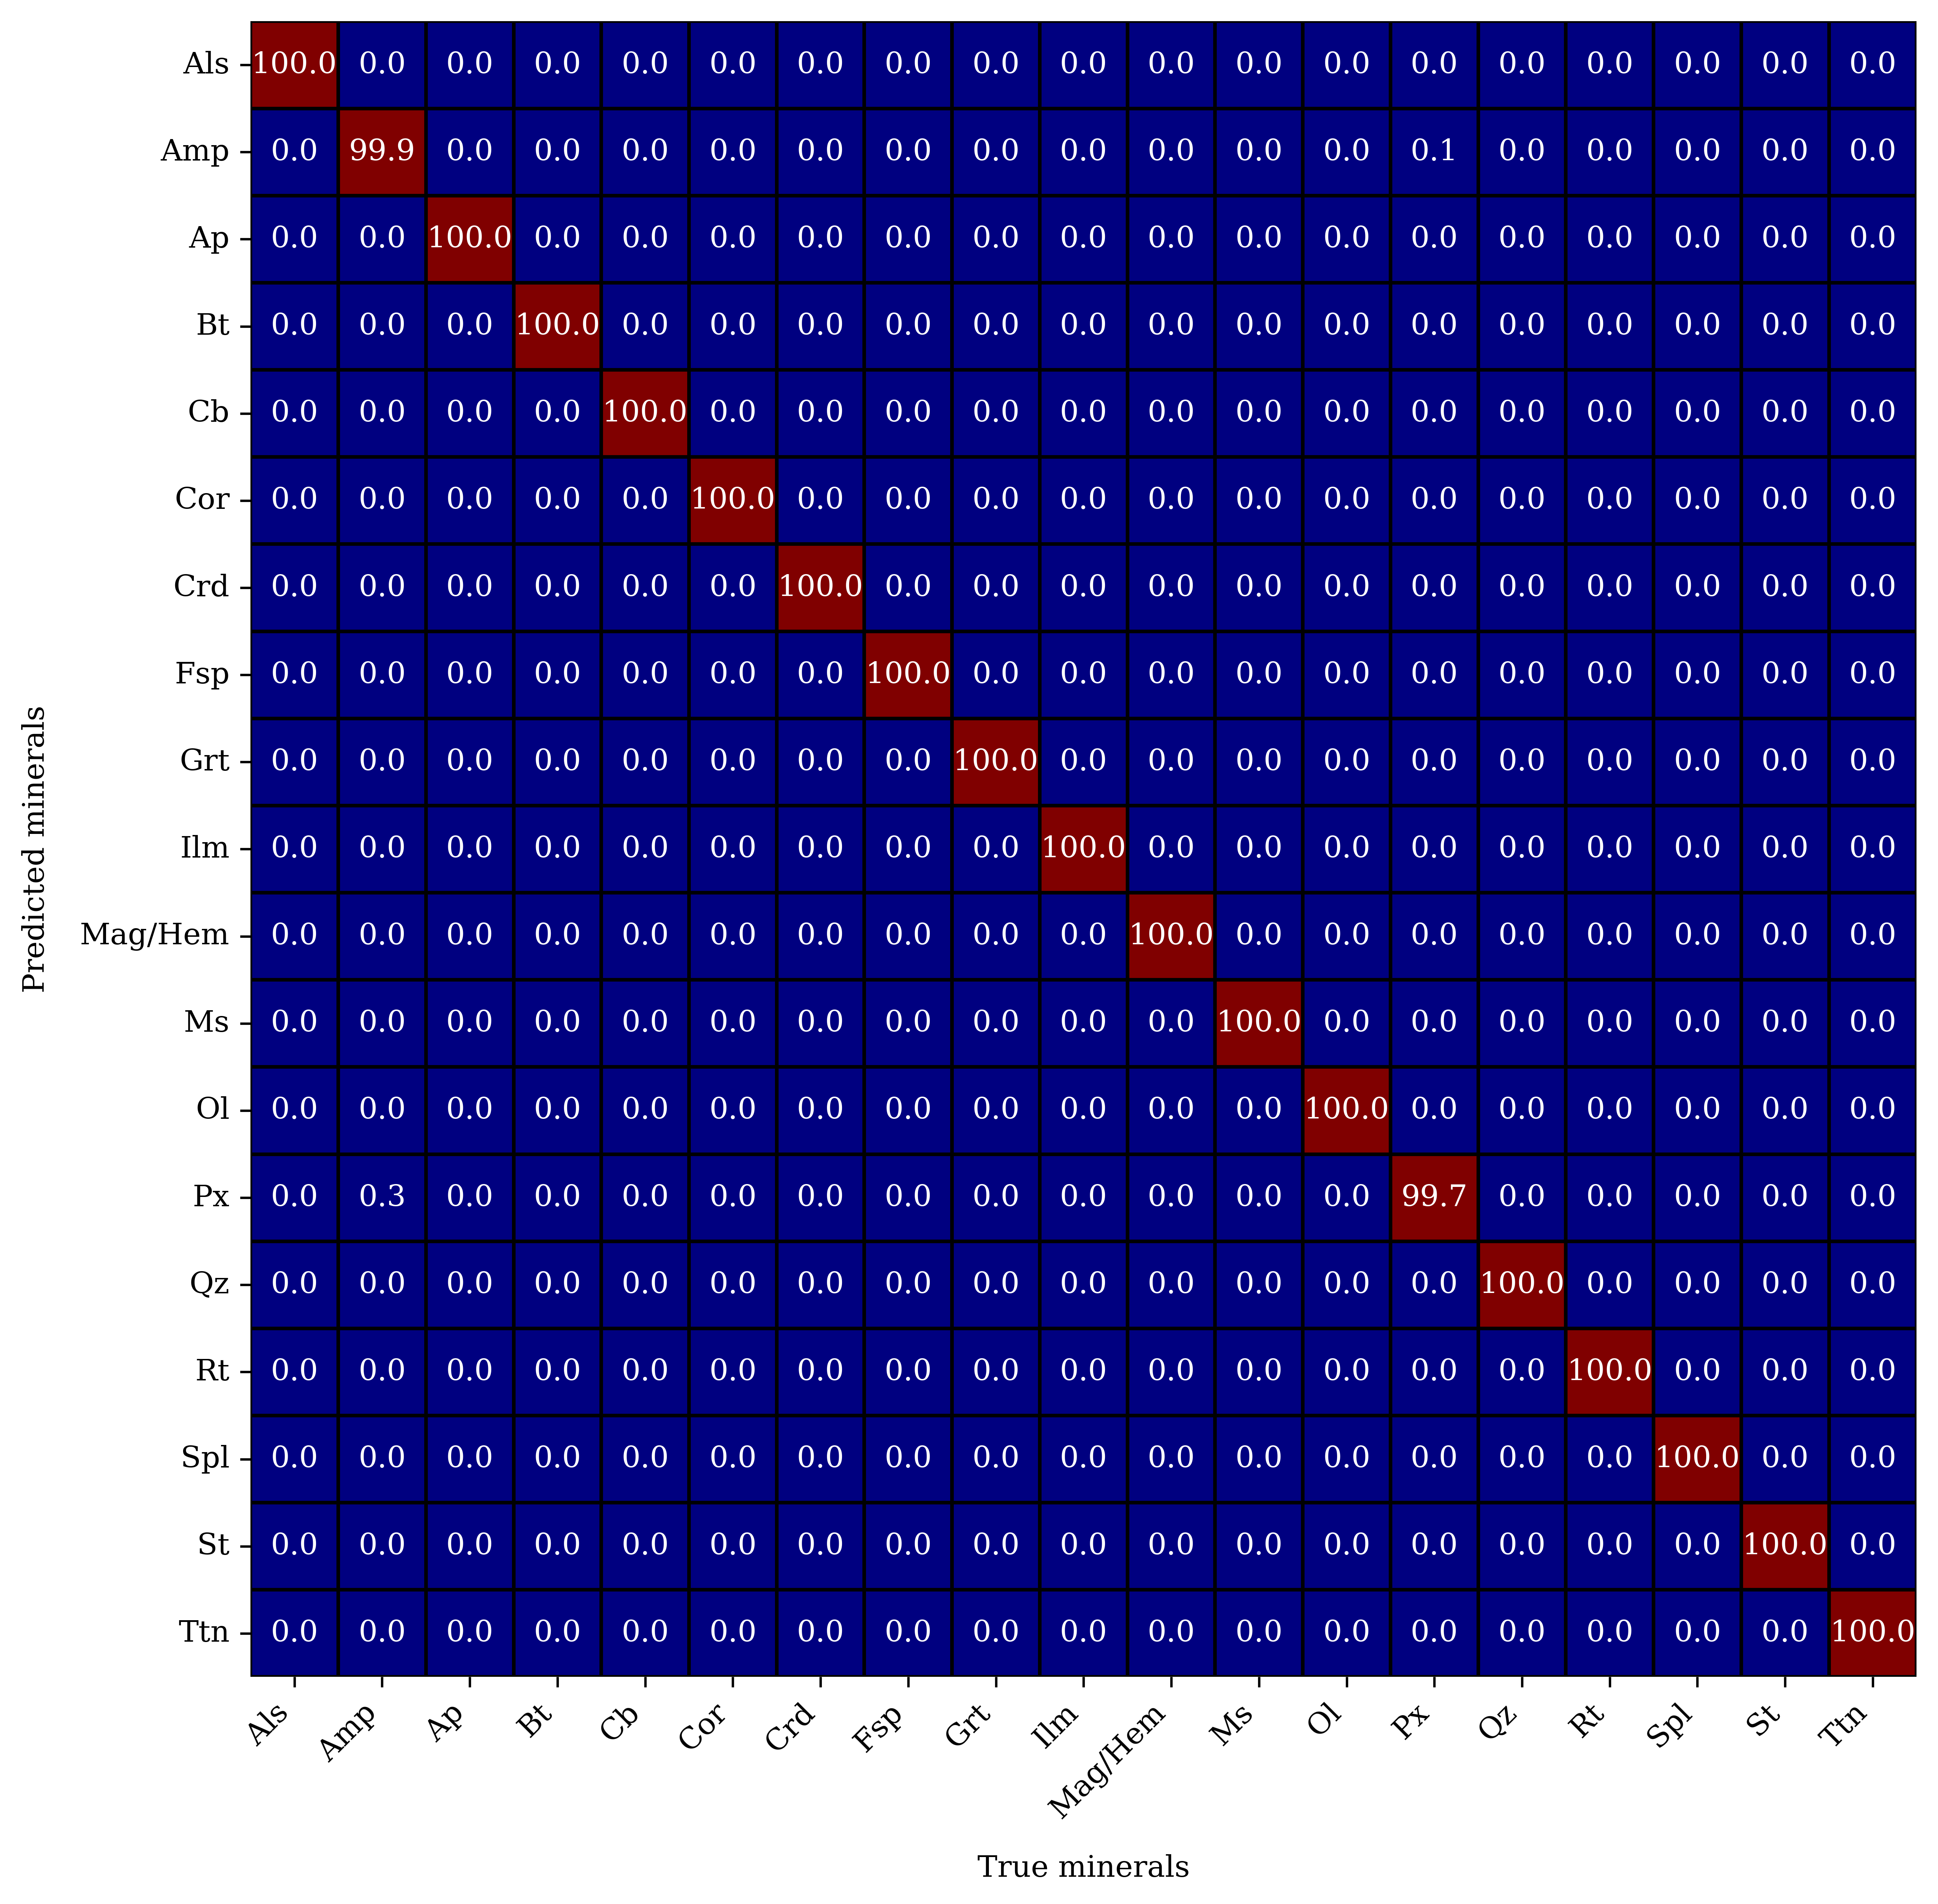

In [97]:
# data =pd.read_excel(file,header=0)
data=data1.copy()
data.loc[(data.Mineral == "opx") | (data.Mineral == "cpx"),"Mineral"] = "px"

data['M'] = data['FeO']+data['MgO']+data['MnO']
data.pop("FeO")
data.pop("MgO")
data.pop("MnO")


data = data[['SiO2', 'TiO2', 'Al2O3', 'M', 'CaO', 'Na2O', 'K2O', 'P2O5','CO2', 'Mineral']]

# data['Al/Si'] = (data["Al2O3"]-data['SiO2'])/(data['SiO2']+data['Al2O3'])

# data = data[['SiO2', 'TiO2', 'Al2O3', 'M', 'CaO', 'A', 'Al/Si',
#        'Mineral', 'Source']]
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.iloc[:,:-1])

labeler = LabelEncoder()
target = labeler.fit_transform(data['Mineral'])

# splitter = StratifiedShuffleSplit(n_splits=2,test_size=testsize,random_state=10)
splitter = StratifiedShuffleSplit(n_splits=2,test_size=testsize)

split, split1 = splitter.split(data_scaled, target)
train_data = data_scaled[split1[0],:]
train_label = target[split1[0]]
test_data = data_scaled[split1[1],:]
test_label = target[split1[1]]

print("\nTesting for FeO+MnO+MgO input data\n")

model.fit(train_data, train_label)
pred_label = model.predict(test_data)
a = round(f1_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
r = round(recall_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
p = round(precision_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
acc_table[0,1] = a
precision_table[0,1] = p
recall_table[0,1] = r
print(round(a,2))
cm = confusion_matrix(test_label, pred_label,normalize='true')*100
cm = pd.DataFrame(cm,columns = labeler.classes_,index=labeler.classes_)
plt.figure(figsize=figsize,dpi=600)
sns.heatmap(cm, annot=True,cmap="jet",fmt='.1f',linewidths=lw,linecolor='black',cbar=False)
plt.xticks(rotation=45,ha='right')
plt.xlabel("True minerals",labelpad=10)
plt.ylabel("Predicted minerals",labelpad=10)
plt.savefig("KNN_C2.pdf",bbox_inches='tight')

for i in range(0,minerals-1):
    test_data1 = test_data[test_label==i]
    test_label1 = test_label[test_label==i]
    pred_label1 = model.predict(test_data1)
    a = round(f1_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    r = round(recall_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    p = round(precision_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    acc_table[i+1,1] = a
    precision_table[i+1,1] = p
    recall_table[i+1,1] = r
    name = labeler.inverse_transform([i])[0]
    print(f"{name}: accuracy: {a}")

# for i in range(0,16):
#     test_data1 = data_scaled[target==i]
#     test_label1 = target[target==i]
#     pred_label1 = model.predict(test_data1)
#     a = round(f1_score(test_label1, pred_label1, average=sample_metrics),4)*100
#     acc_table[i+1,0] = a
#     name = labeler.inverse_transform([i])[0]
#     print(f"{name}: accuracy: {a}")

pred_label = model.predict(data_scaled)
test_data_df = data.copy()
test_data_df['Pred'] = labeler.inverse_transform(pred_label)
test_data_df_mismatch = test_data_df[test_data_df['Mineral'] != test_data_df['Pred']]

In [98]:
test_data_df_mismatch

,SiO2,TiO2,Al2O3,M,CaO,Na2O,K2O,P2O5,CO2,Mineral,Pred
S No.,,,,,,,,,,,
32151,48.7,0.0,2.5,35.3,13.5,0.0,0.0,0.0,0.0,Amp,Px
35515,49.5,0.0,4.8,30.7,15.0,0.0,0.0,0.0,0.0,Amp,Px
29073,50.8,0.0,1.8,33.5,13.9,0.0,0.0,0.0,0.0,Px,Amp
29214,51.3,0.0,1.8,43.0,3.9,0.0,0.0,0.0,0.0,Px,Amp
29218,50.4,0.0,2.7,34.6,12.4,0.0,0.0,0.0,0.0,Px,Amp
29835,50.9,0.0,0.0,27.2,20.1,1.9,0.0,0.0,0.0,Px,Amp
29894,54.0,0.0,0.0,43.5,2.6,0.0,0.0,0.0,0.0,Px,Amp
28247,48.7,0.0,2.7,35.5,13.1,0.0,0.0,0.0,0.0,Px,Amp
28203,49.3,0.0,2.0,33.6,15.2,0.0,0.0,0.0,0.0,Px,Amp


In [99]:
# testres = model.cv_results_
# testres = pd.DataFrame(testres)
# testres.to_excel("/Users/aditya/Documents/Research/Mineral identifier ann IISER Mohali/Additional machine learning algos/KNN/KNN_gridsearch_result_FeO+MnO+MgO.xlsx")


Testing for FeO+MnO+MgO and Na2O+K2O input data

99.97
Als: accuracy: 100.0
Amp: accuracy: 49.96
Ap: accuracy: 100.0
Bt: accuracy: 100.0
Cb: accuracy: 100.0
Cor: accuracy: 100.0
Crd: accuracy: 100.0
Fsp: accuracy: 100.0
Grt: accuracy: 100.0
Ilm: accuracy: 100.0
Mag/Hem: accuracy: 100.0
Ms: accuracy: 100.0
Ol: accuracy: 100.0
Px: accuracy: 33.28
Qz: accuracy: 100.0
Rt: accuracy: 100.0
Spl: accuracy: 100.0
St: accuracy: 100.0
Ttn: accuracy: 100.0


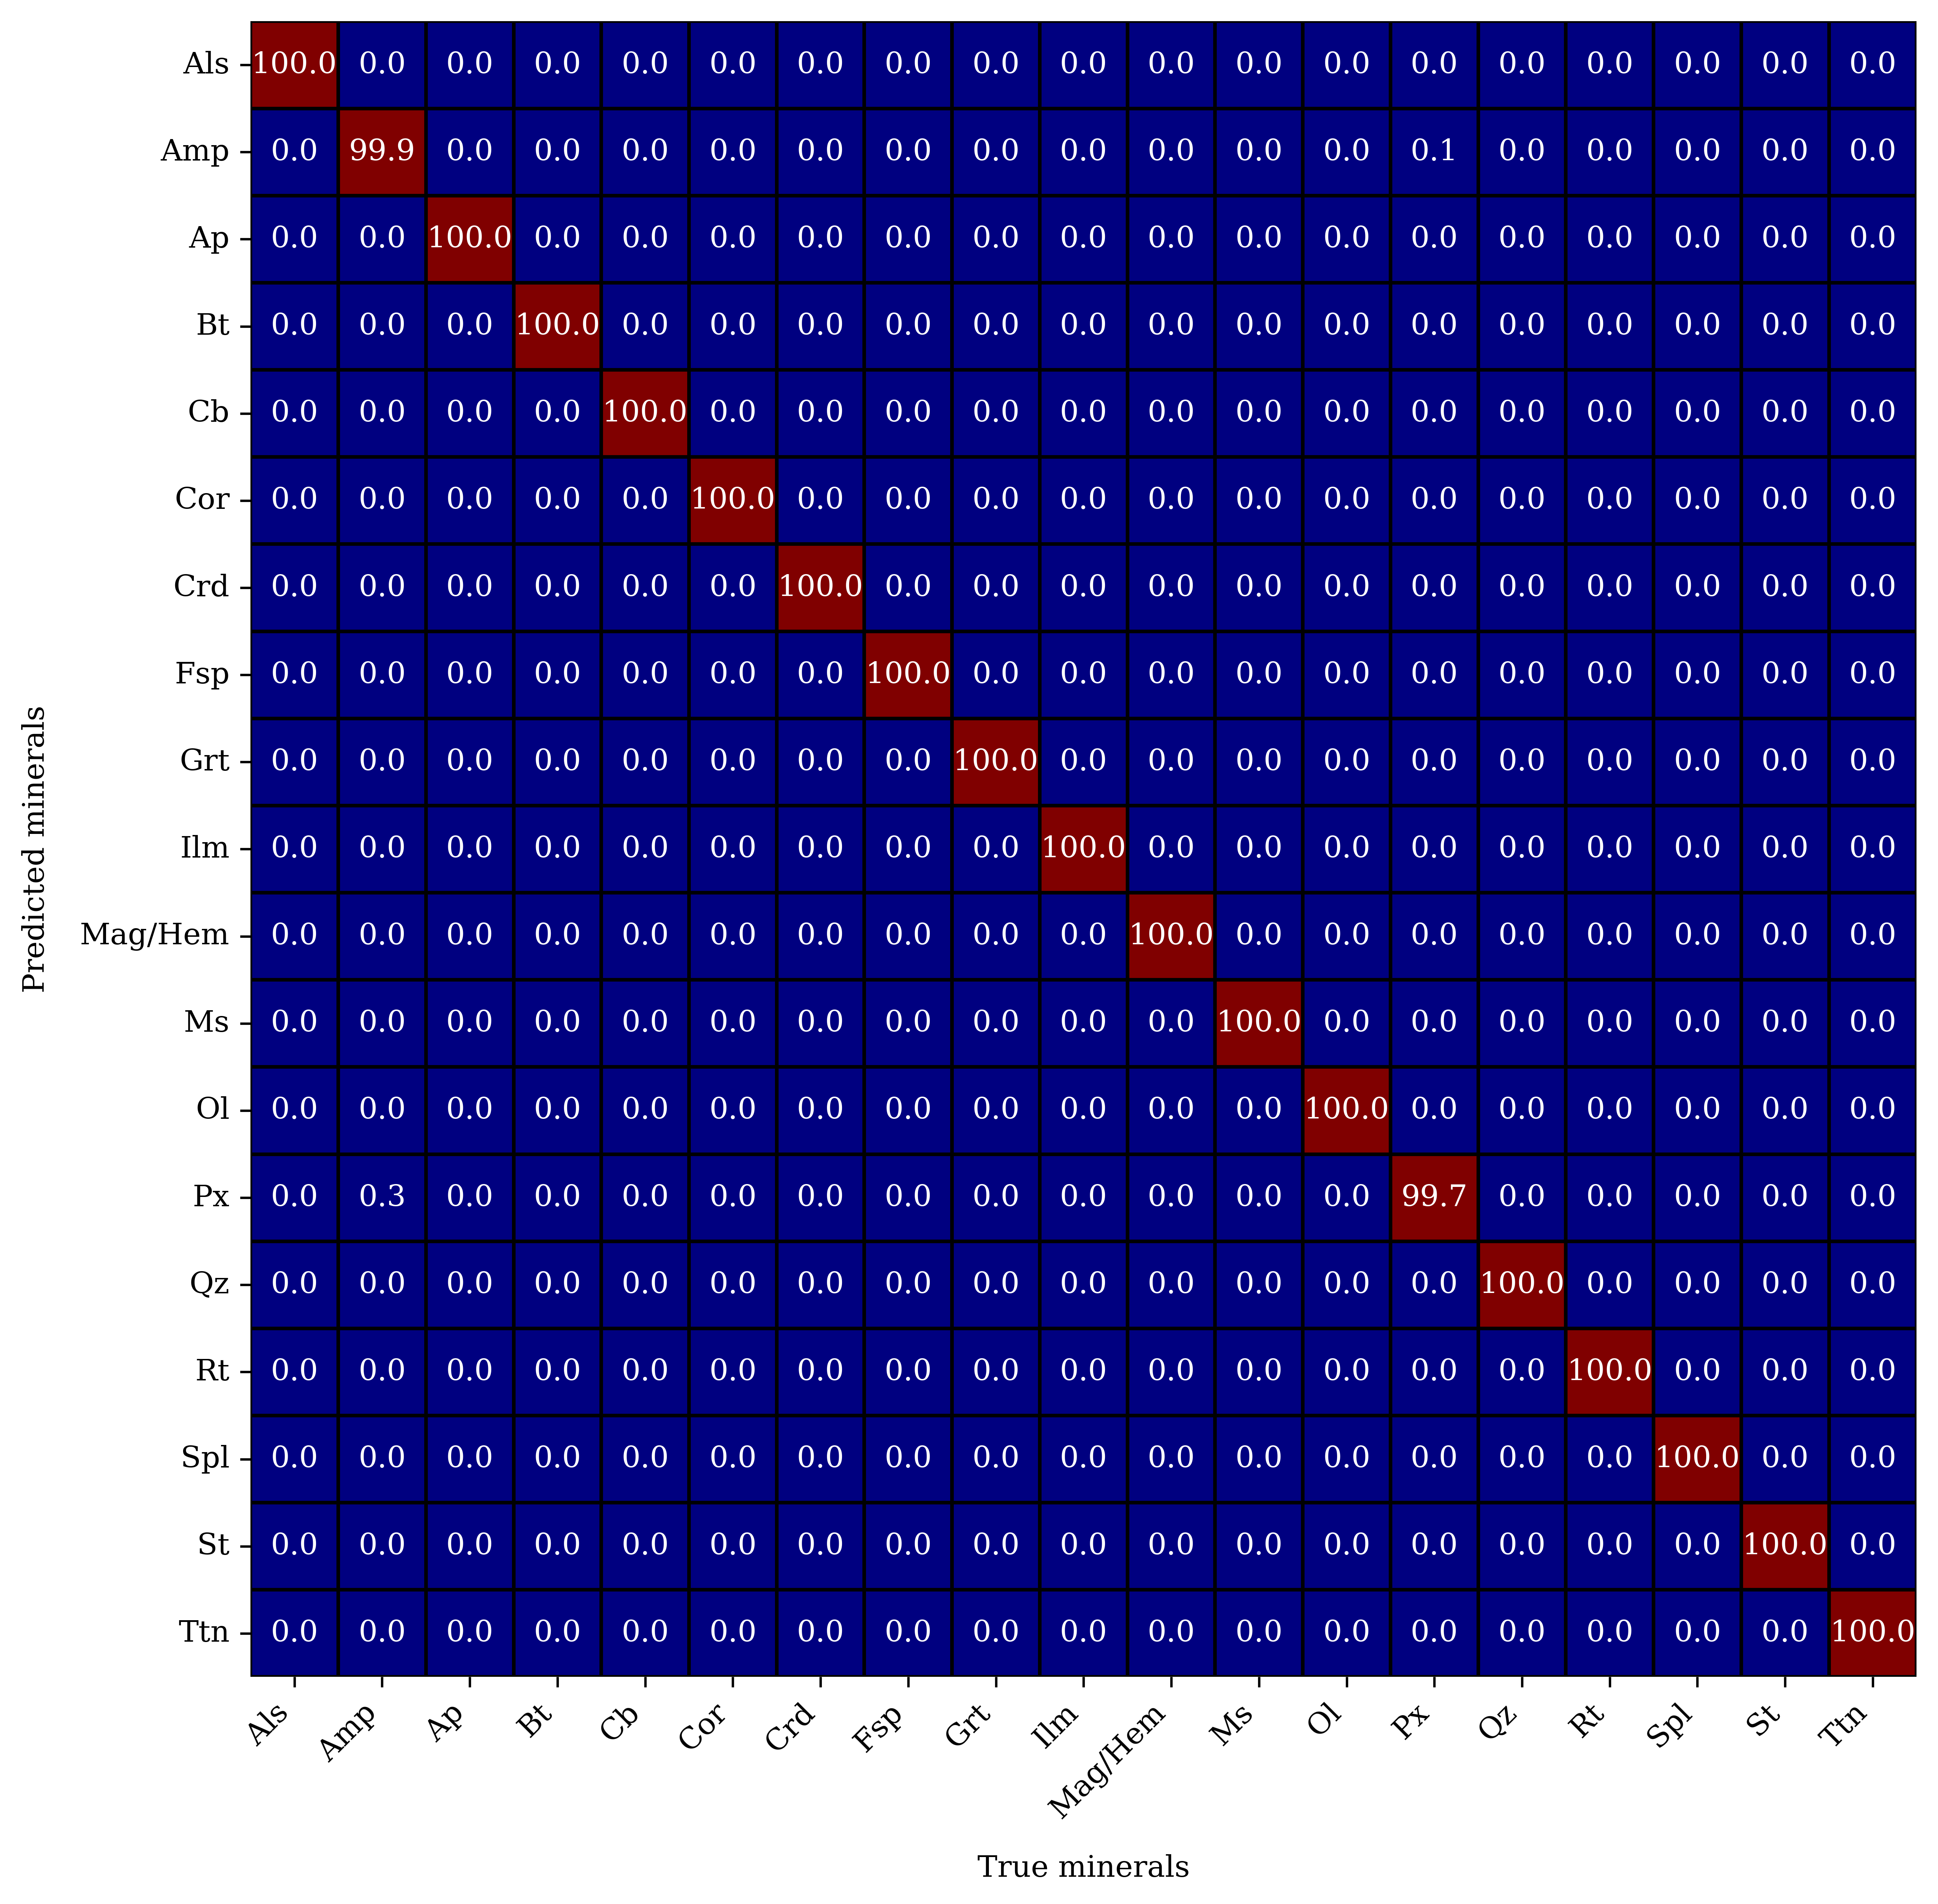

In [100]:
# data =pd.read_excel(file,header=0)
data = data1.copy()
data.loc[(data.Mineral == "opx") | (data.Mineral == "cpx"),"Mineral"] = "px"

data['M'] = data['FeO']+data['MgO']+data['MnO']#+data['CaO']
data.pop("FeO")
data.pop("MgO")
data.pop("MnO")
# data.pop("CaO")

data['A'] = data["K2O"]+data["Na2O"]
data.pop("K2O")
data.pop("Na2O")
data = data[['SiO2', 'TiO2', 'Al2O3', 'M', 'CaO', 'A', 'P2O5', 'CO2','Mineral']]

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.iloc[:,:-1])

labeler = LabelEncoder()
target = labeler.fit_transform(data['Mineral'])

# splitter = StratifiedShuffleSplit(n_splits=2,test_size=testsize,random_state=2)
splitter = StratifiedShuffleSplit(n_splits=2,test_size=testsize)
split, split1 = splitter.split(data_scaled, target)
train_data = data_scaled[split1[0],:]
train_label = target[split1[0]]
test_data = data_scaled[split1[1],:]
test_label = target[split1[1]]

print("\nTesting for FeO+MnO+MgO and Na2O+K2O input data\n")

model.fit(train_data, train_label)
pred_label = model.predict(test_data)
# a = round(f1_score(test_label, pred_label, average=over_metrics),4)*100
# print(round(a,2))
# acc_table[0,2] = a

a = round(f1_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
r = round(recall_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
p = round(precision_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
acc_table[0,2] = a
precision_table[0,2] = p
recall_table[0,2] = r
# print(round(a,2p = pd.DataFrame(confusion_matrix(test_label, pred_label),columns=labeler.classes_,index=labeler.classes_plt.figure(figsize=(16,16),dpi=600)
print(round(a,2))
cm = confusion_matrix(test_label, pred_label,normalize='true')*100
cm = pd.DataFrame(cm,columns = labeler.classes_,index=labeler.classes_)
plt.figure(figsize=figsize,dpi=600)
sns.heatmap(cm, annot=True,cmap="jet",fmt='.1f',linewidths=lw,linecolor='black',cbar=False)
plt.xticks(rotation=45,ha='right')
plt.xlabel("True minerals",labelpad=10)
plt.ylabel("Predicted minerals",labelpad=10)
plt.savefig("KNN_C3.pdf",bbox_inches='tight')

for i in range(0,minerals-1):
    test_data1 = test_data[test_label==i]
    test_label1 = test_label[test_label==i]
    pred_label1 = model.predict(test_data1)
    a = round(f1_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    r = round(recall_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    p = round(precision_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    acc_table[i+1,2] = a
    precision_table[i+1,2] = p
    recall_table[i+1,2] = r
    acc_table[i+1,2] = a
    name = labeler.inverse_transform([i])[0]
    print(f"{name}: accuracy: {a}")

In [101]:
test_data_df_mismatch

,SiO2,TiO2,Al2O3,M,CaO,Na2O,K2O,P2O5,CO2,Mineral,Pred
S No.,,,,,,,,,,,
32151,48.7,0.0,2.5,35.3,13.5,0.0,0.0,0.0,0.0,Amp,Px
35515,49.5,0.0,4.8,30.7,15.0,0.0,0.0,0.0,0.0,Amp,Px
29073,50.8,0.0,1.8,33.5,13.9,0.0,0.0,0.0,0.0,Px,Amp
29214,51.3,0.0,1.8,43.0,3.9,0.0,0.0,0.0,0.0,Px,Amp
29218,50.4,0.0,2.7,34.6,12.4,0.0,0.0,0.0,0.0,Px,Amp
29835,50.9,0.0,0.0,27.2,20.1,1.9,0.0,0.0,0.0,Px,Amp
29894,54.0,0.0,0.0,43.5,2.6,0.0,0.0,0.0,0.0,Px,Amp
28247,48.7,0.0,2.7,35.5,13.1,0.0,0.0,0.0,0.0,Px,Amp
28203,49.3,0.0,2.0,33.6,15.2,0.0,0.0,0.0,0.0,Px,Amp


In [102]:
# testres = model.cv_results_
# testres = pd.DataFrame(testres)
# testres.to_excel("/Users/aditya/Documents/Research/Mineral identifier ann IISER Mohali/Additional machine learning algos/KNN/KNN_gridsearch_result_FeO+MnO+MgO and Na2O+K2O.xlsx")


Testing for FeO+MnO+MgO+CaO and CaO+Na2O+K2O input data

99.99
Als: accuracy: 100.0
Amp: accuracy: 100.0
Ap: accuracy: 100.0
Bt: accuracy: 100.0
Cb: accuracy: 100.0
Cor: accuracy: 100.0
Crd: accuracy: 100.0
Fsp: accuracy: 100.0
Grt: accuracy: 100.0
Ilm: accuracy: 100.0
Mag/Hem: accuracy: 100.0
Ms: accuracy: 100.0
Ol: accuracy: 100.0
Px: accuracy: 49.94
Qz: accuracy: 100.0
Rt: accuracy: 100.0
Spl: accuracy: 100.0
St: accuracy: 100.0
Ttn: accuracy: 100.0


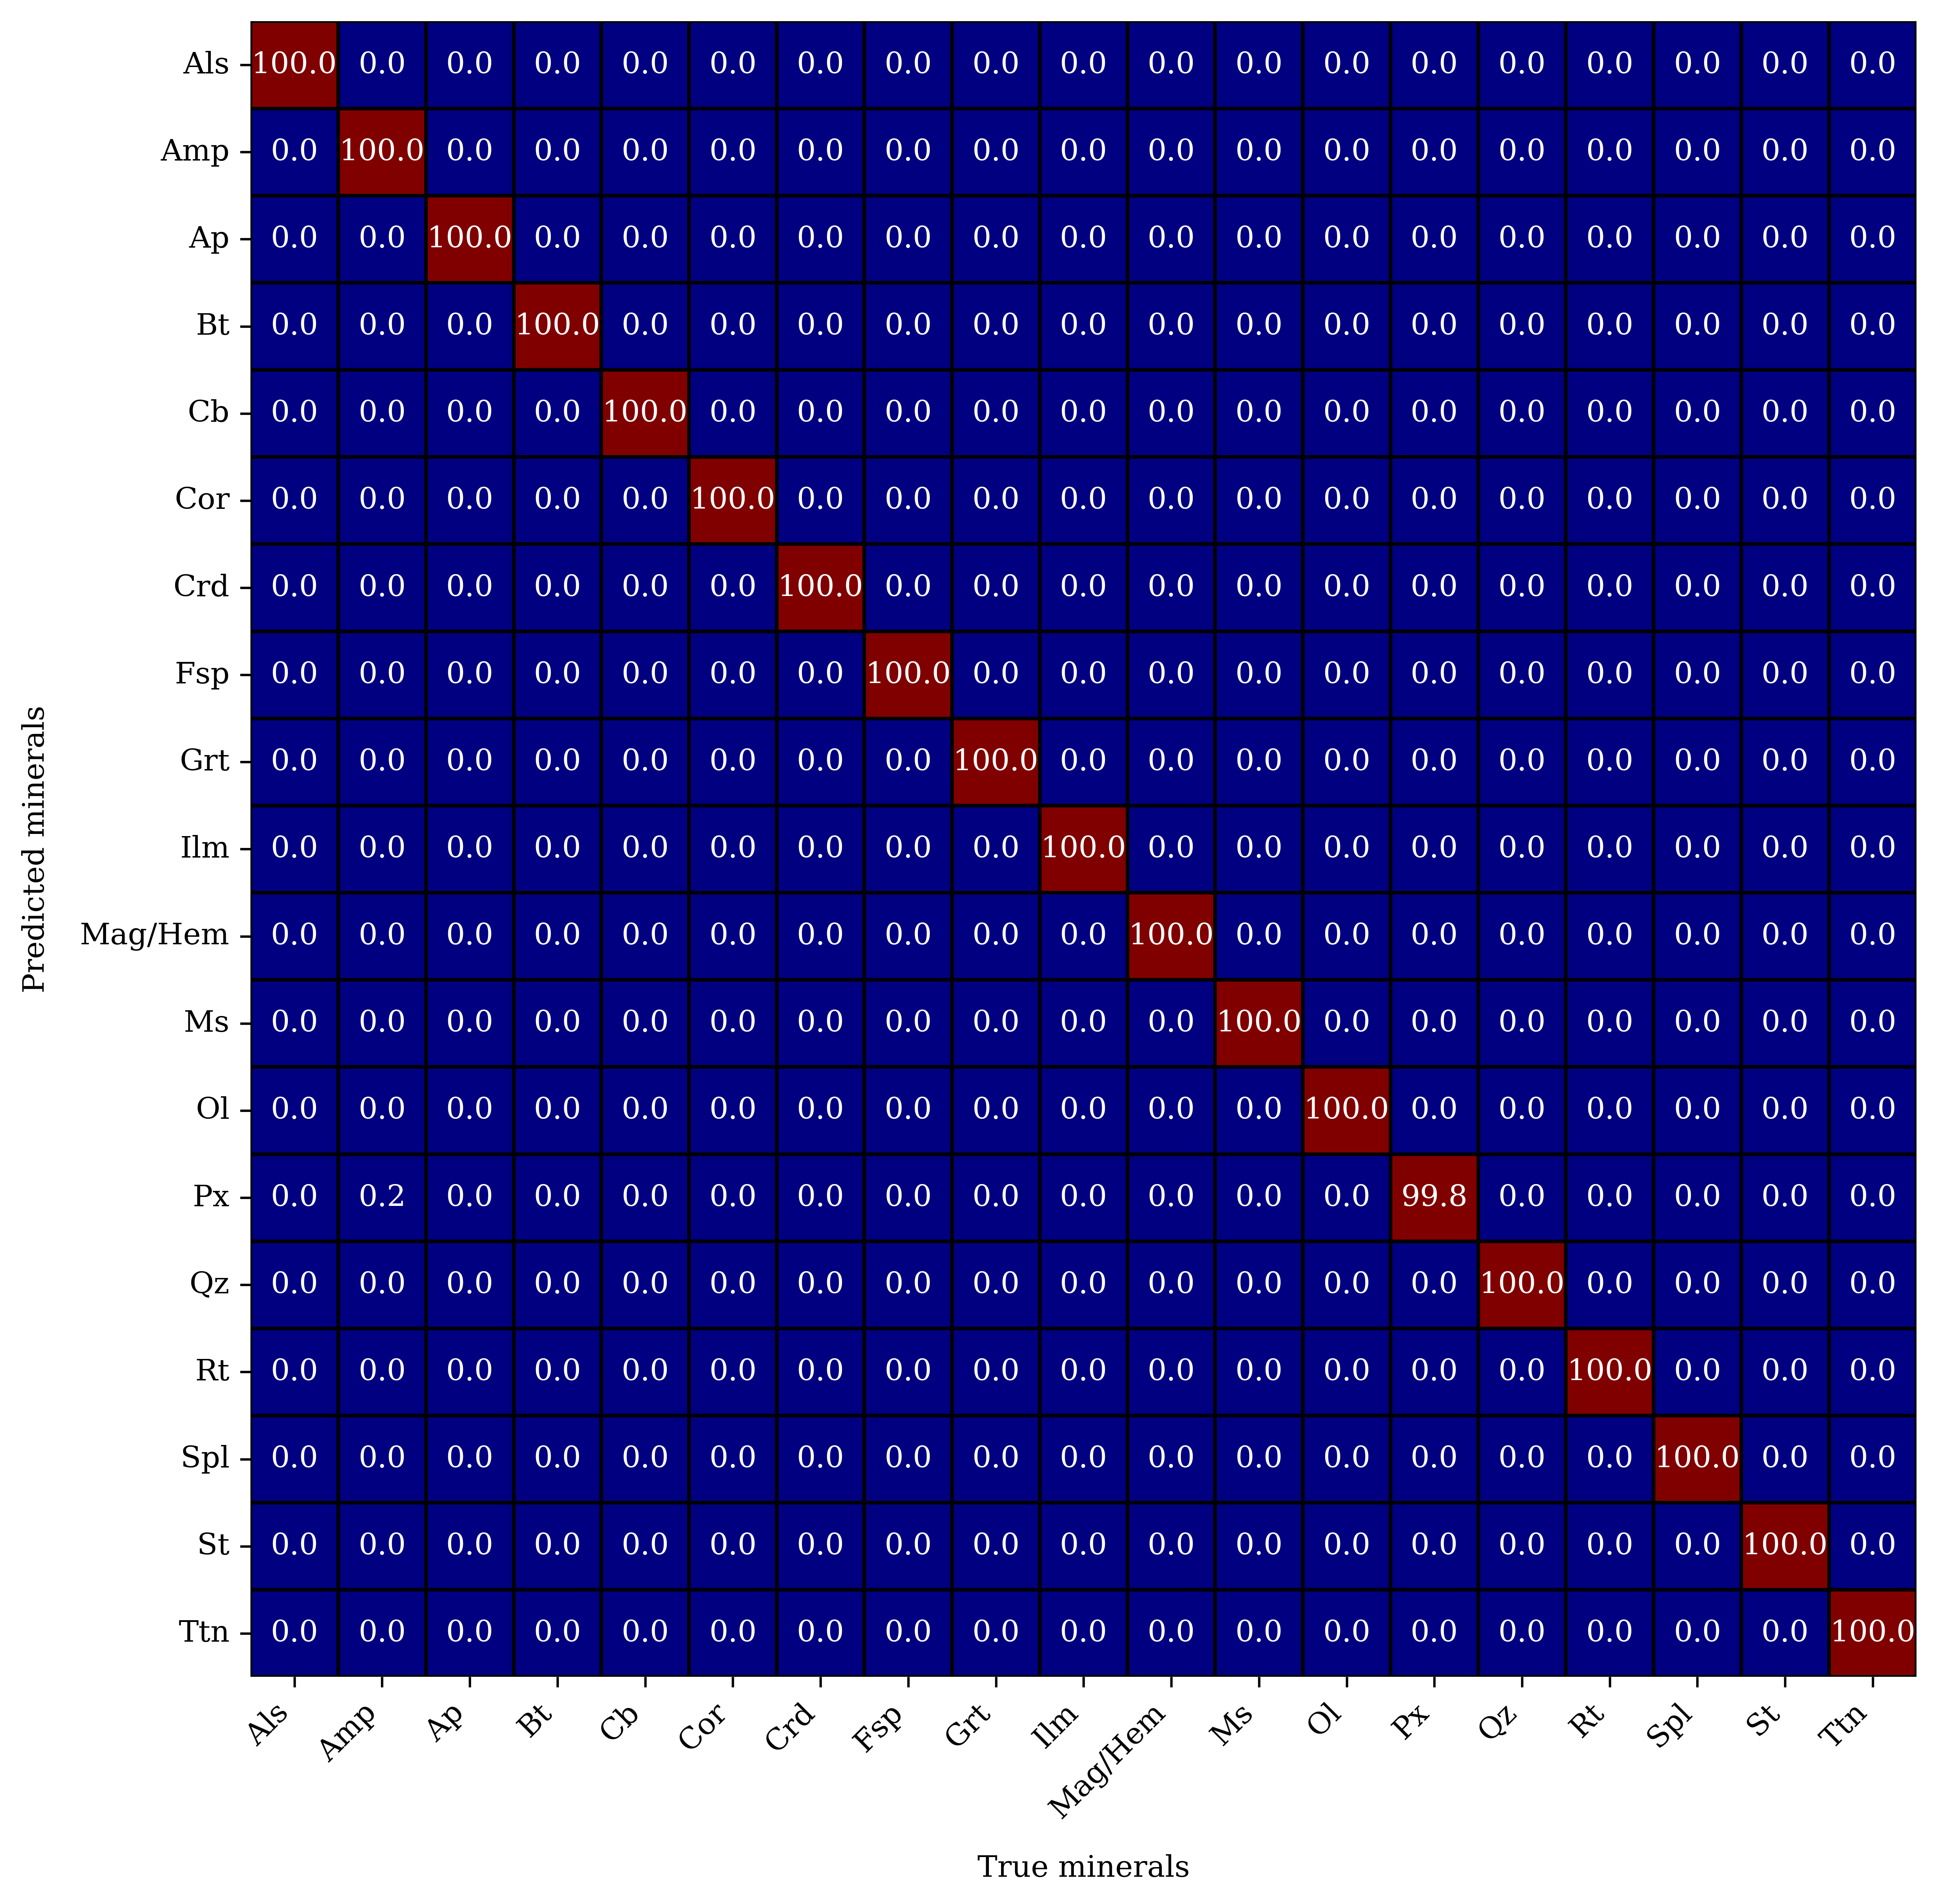

In [103]:
#%%
# data =pd.read_excel(r"C:\Users\naik3\Documents\Research\Mineral identifier ann IISER Mohali\new random comp generator\GEOROC data\processed minerals\molar tables\compiled1.xlsx",header=0)
# data =pd.read_excel(file,header=0)
data = data1.copy()
data.loc[(data.Mineral == "opx") | (data.Mineral == "cpx"),"Mineral"] = "px"

data['M'] = data['FeO']+data['MgO']+data['MnO']+data['CaO']
data.pop("FeO")
data.pop("MgO")
data.pop("MnO")


# data['A1'] = data["Na2O"]+data['CaO']
# data['A2'] = data["K2O"]+data["Na2O"]
data['A'] = data["Na2O"]+(2*data['CaO'])+data['K2O']

data.pop("K2O")
data.pop("Na2O")
data.pop("CaO")

# data = data[['SiO2', 'TiO2', 'Al2O3', 'M', 'A1', 'A2', 'P2O5','CO2', 'Mineral', 'Source']]
data = data[['SiO2', 'TiO2', 'Al2O3', 'M', 'A', 'P2O5','CO2', 'Mineral']]

# data['Al/Si'] = (data["Al2O3"]-data['SiO2'])/(data['SiO2']+data['Al2O3'])

# data = data[['SiO2', 'TiO2', 'Al2O3', 'M', 'CaO', 'A', 'Al/Si',
#        'Mineral', 'Source']]
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.iloc[:,:-1])

labeler = LabelEncoder()
target = labeler.fit_transform(data['Mineral'])

splitter = StratifiedShuffleSplit(n_splits=2,test_size=testsize,random_state=2)
split, split1 = splitter.split(data_scaled, target)
train_data = data_scaled[split1[0],:]
train_label = target[split1[0]]
test_data = data_scaled[split1[1],:]
test_label = target[split1[1]]

print("\nTesting for FeO+MnO+MgO+CaO and CaO+Na2O+K2O input data\n")

model.fit(train_data, train_label)
pred_label = model.predict(test_data)
# a = round(f1_score(test_label, pred_label, average=over_metrics),4)*100
# acc_table[0,3] = a

a = round(f1_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
r = round(recall_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
p = round(precision_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
acc_table[0,3] = a
precision_table[0,3] = p
recall_table[0,3] = r
print(round(a,2))
cm = confusion_matrix(test_label, pred_label,normalize='true')*100
cm = pd.DataFrame(cm,columns = labeler.classes_,index=labeler.classes_)
plt.figure(figsize=figsize,dpi=600)
sns.heatmap(cm, annot=True,cmap="jet",fmt='.1f',linewidths=lw,linecolor='black',cbar=False)
plt.xticks(rotation=45,ha='right')
plt.xlabel("True minerals",labelpad=10)
plt.ylabel("Predicted minerals",labelpad=10)
plt.savefig("KNN_C4.pdf",bbox_inches='tight')

for i in range(0,minerals-1):
    test_data1 = test_data[test_label==i]
    test_label1 = test_label[test_label==i]
    pred_label1 = model.predict(test_data1)
    a = round(f1_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    r = round(recall_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    p = round(precision_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    acc_table[i+1,3] = a
    precision_table[i+1,3] = p
    recall_table[i+1,3] = r
    acc_table[i+1,3] = a
    name = labeler.inverse_transform([i])[0]
    print(f"{name}: accuracy: {a}")

In [59]:
test_data_df_mismatch

,SiO2,TiO2,Al2O3,M,CaO,Na2O,K2O,P2O5,CO2,Mineral,Pred
S No.,,,,,,,,,,,
31822,48.7,0.0,0.0,38.2,13.2,0.0,0.0,0.0,0.0,Amp,Px
7233,61.8,0.0,30.2,0.0,0.0,5.2,2.7,0.0,0.0,Ms,Fsp
7232,61.2,0.0,30.0,0.0,0.0,6.9,2.0,0.0,0.0,Ms,Fsp
29185,49.3,0.0,1.9,35.2,13.7,0.0,0.0,0.0,0.0,Px,Amp
29215,53.5,0.0,0.0,41.6,4.9,0.0,0.0,0.0,0.0,Px,Amp
29138,48.2,0.0,3.4,32.4,15.9,0.0,0.0,0.0,0.0,Px,Amp
28559,49.7,0.0,4.8,30.4,15.0,0.0,0.0,0.0,0.0,Px,Amp
28739,48.3,0.0,2.5,35.4,13.8,0.0,0.0,0.0,0.0,Px,Amp
28247,48.7,0.0,2.7,35.5,13.1,0.0,0.0,0.0,0.0,Px,Amp


In [60]:
# testres = model.cv_results_
# testres = pd.DataFrame(testres)
# testres.to_excel("/Users/aditya/Documents/Research/Mineral identifier ann IISER Mohali/Additional machine learning algos/KNN/KNN_gridsearch_result_FeO+MnO+MgO+CaO and CaO+Na2O+K2O.xlsx")


Testing for PCA (n=5) transformed input data

99.91
Als: accuracy: 100.0
Amp: accuracy: 99.96000000000001
Ap: accuracy: 100.0
Bt: accuracy: 99.95
Cb: accuracy: 100.0
Cor: accuracy: 100.0
Crd: accuracy: 100.0
Fsp: accuracy: 100.0
Grt: accuracy: 100.0
Ilm: accuracy: 100.0
Mag/Hem: accuracy: 100.0
Ms: accuracy: 99.76
Ol: accuracy: 100.0
Px: accuracy: 99.81
Qz: accuracy: 100.0
Rt: accuracy: 100.0
Spl: accuracy: 100.0
St: accuracy: 100.0
Ttn: accuracy: 100.0

Testing for PCA (n=6) transformed input data

99.9
Als: accuracy: 100.0
Amp: accuracy: 99.96000000000001
Ap: accuracy: 100.0
Bt: accuracy: 99.95
Cb: accuracy: 100.0
Cor: accuracy: 100.0
Crd: accuracy: 100.0
Fsp: accuracy: 100.0
Grt: accuracy: 99.91
Ilm: accuracy: 100.0
Mag/Hem: accuracy: 100.0
Ms: accuracy: 99.76
Ol: accuracy: 100.0
Px: accuracy: 99.81
Qz: accuracy: 100.0
Rt: accuracy: 100.0
Spl: accuracy: 100.0
St: accuracy: 100.0
Ttn: accuracy: 100.0

Testing for PCA (n=7) transformed input data

99.88
Als: accuracy: 100.0
Amp: accu

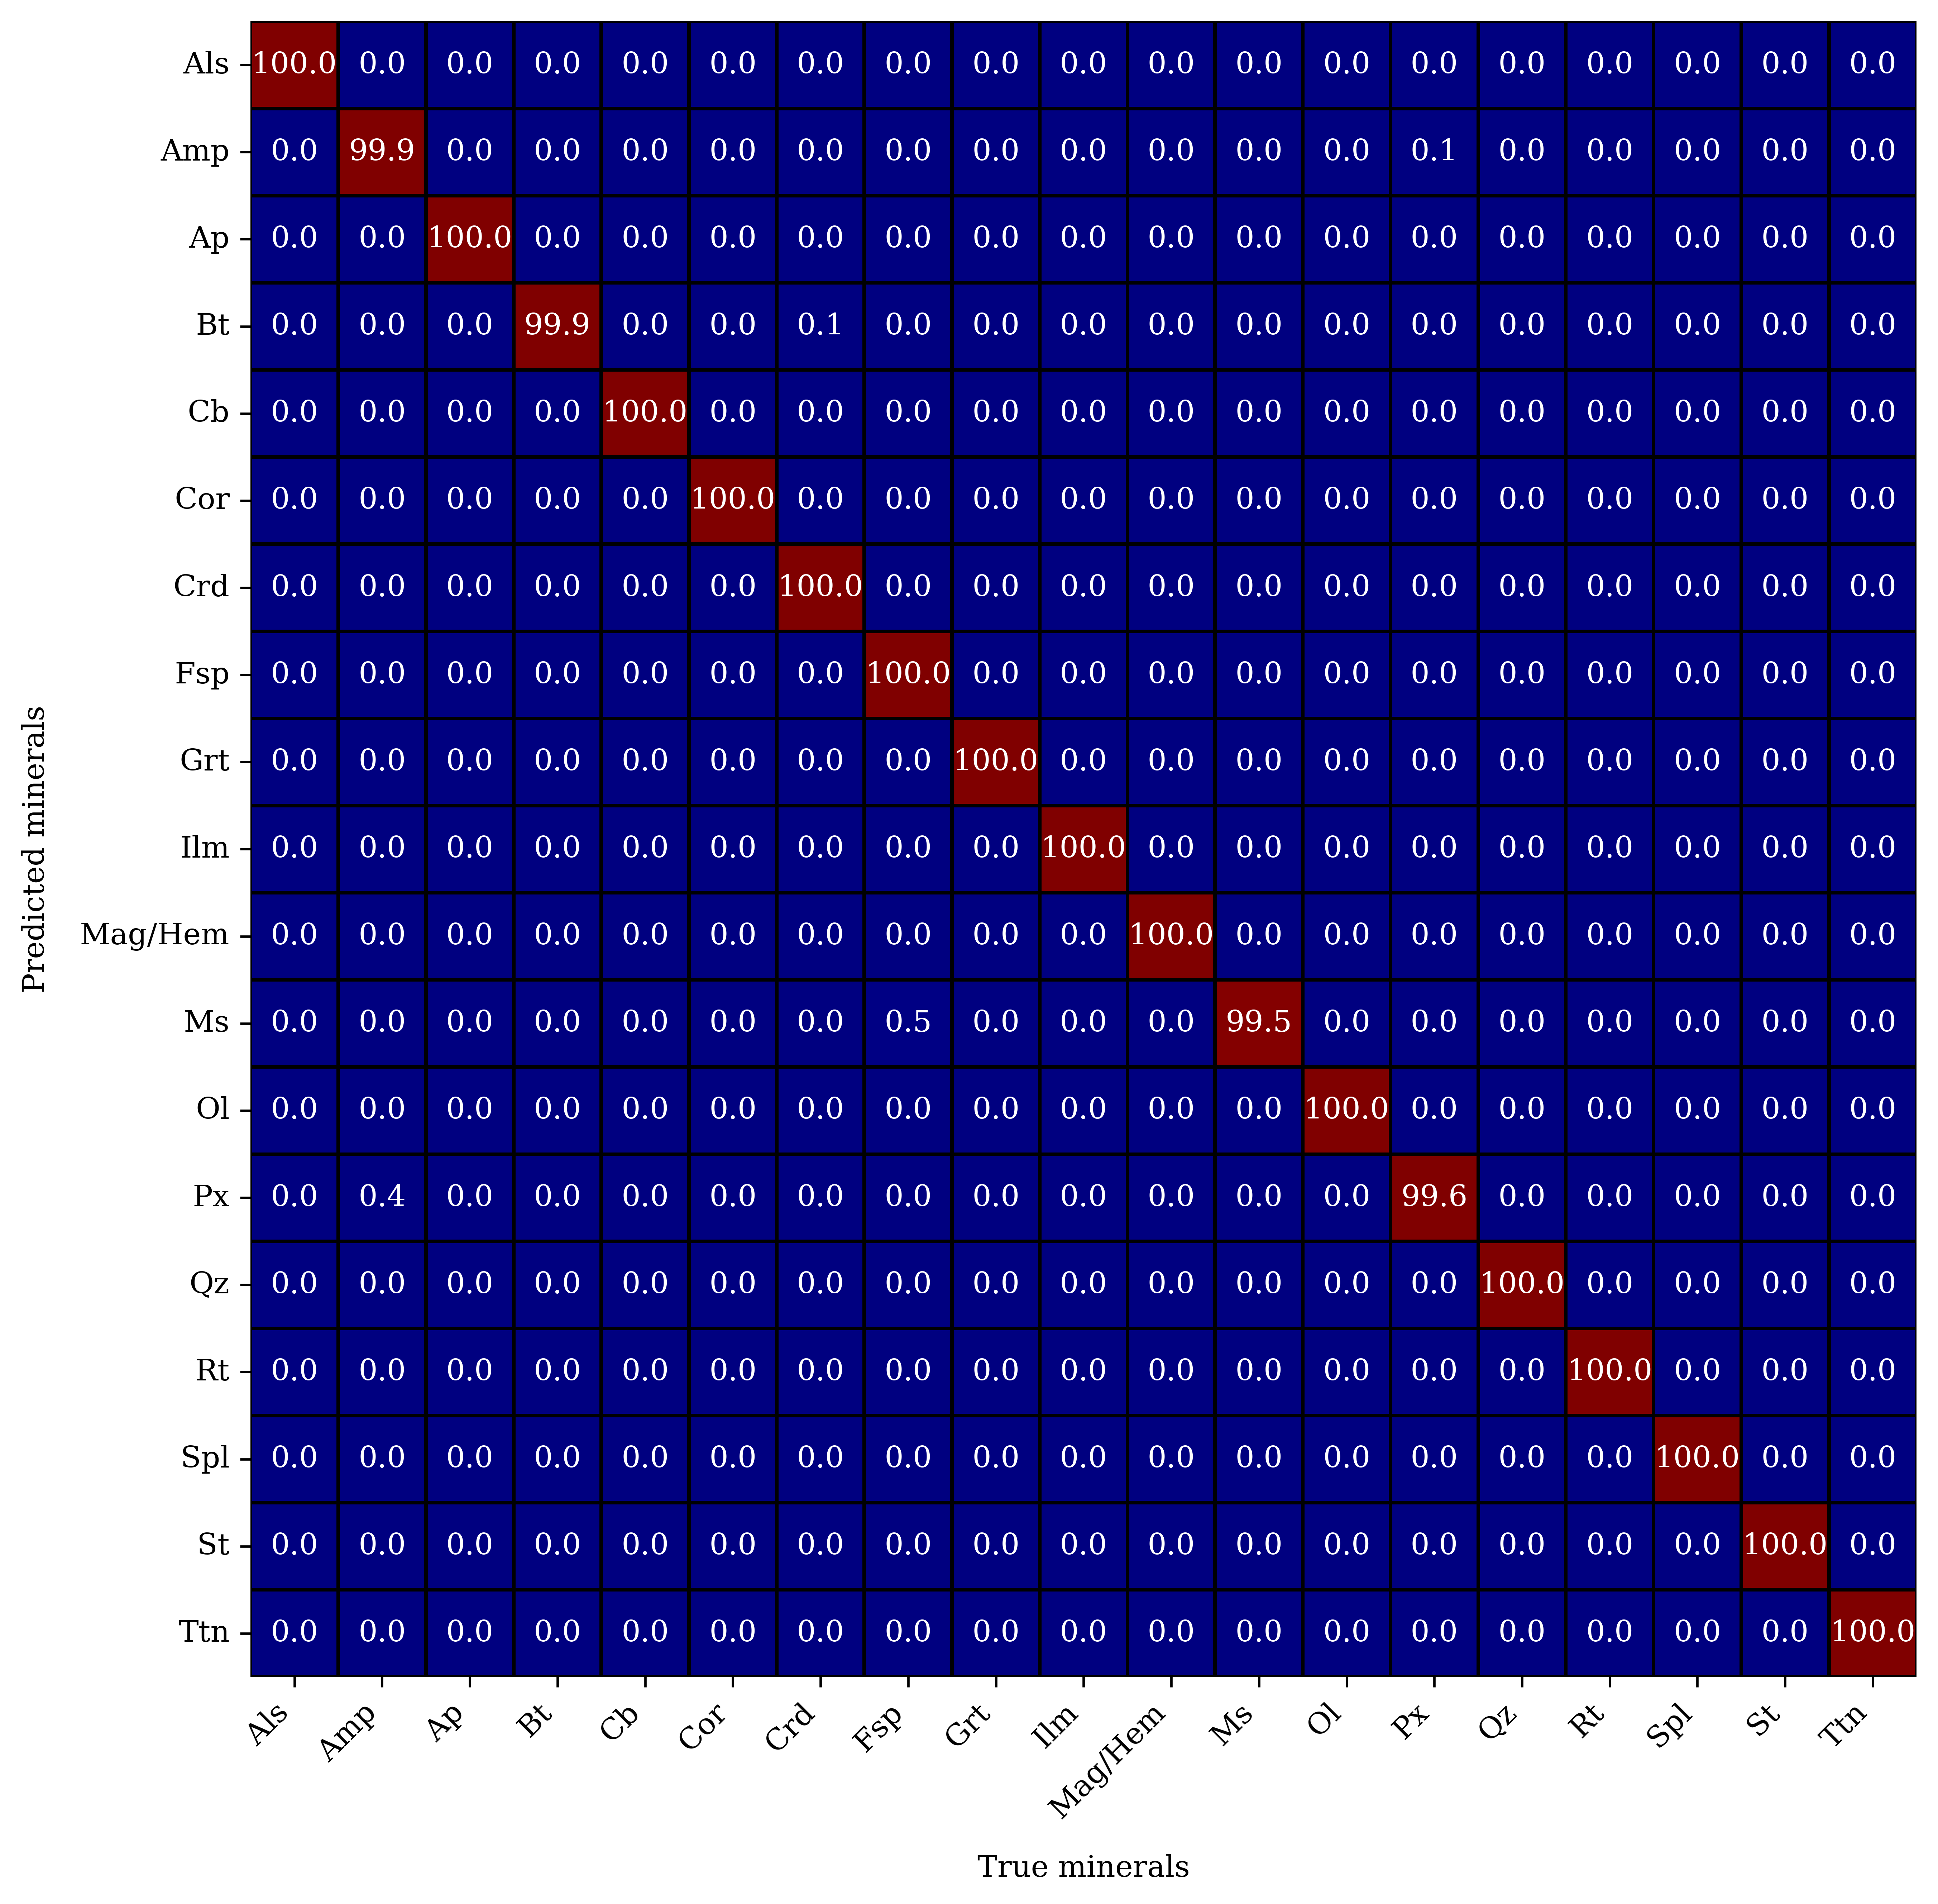

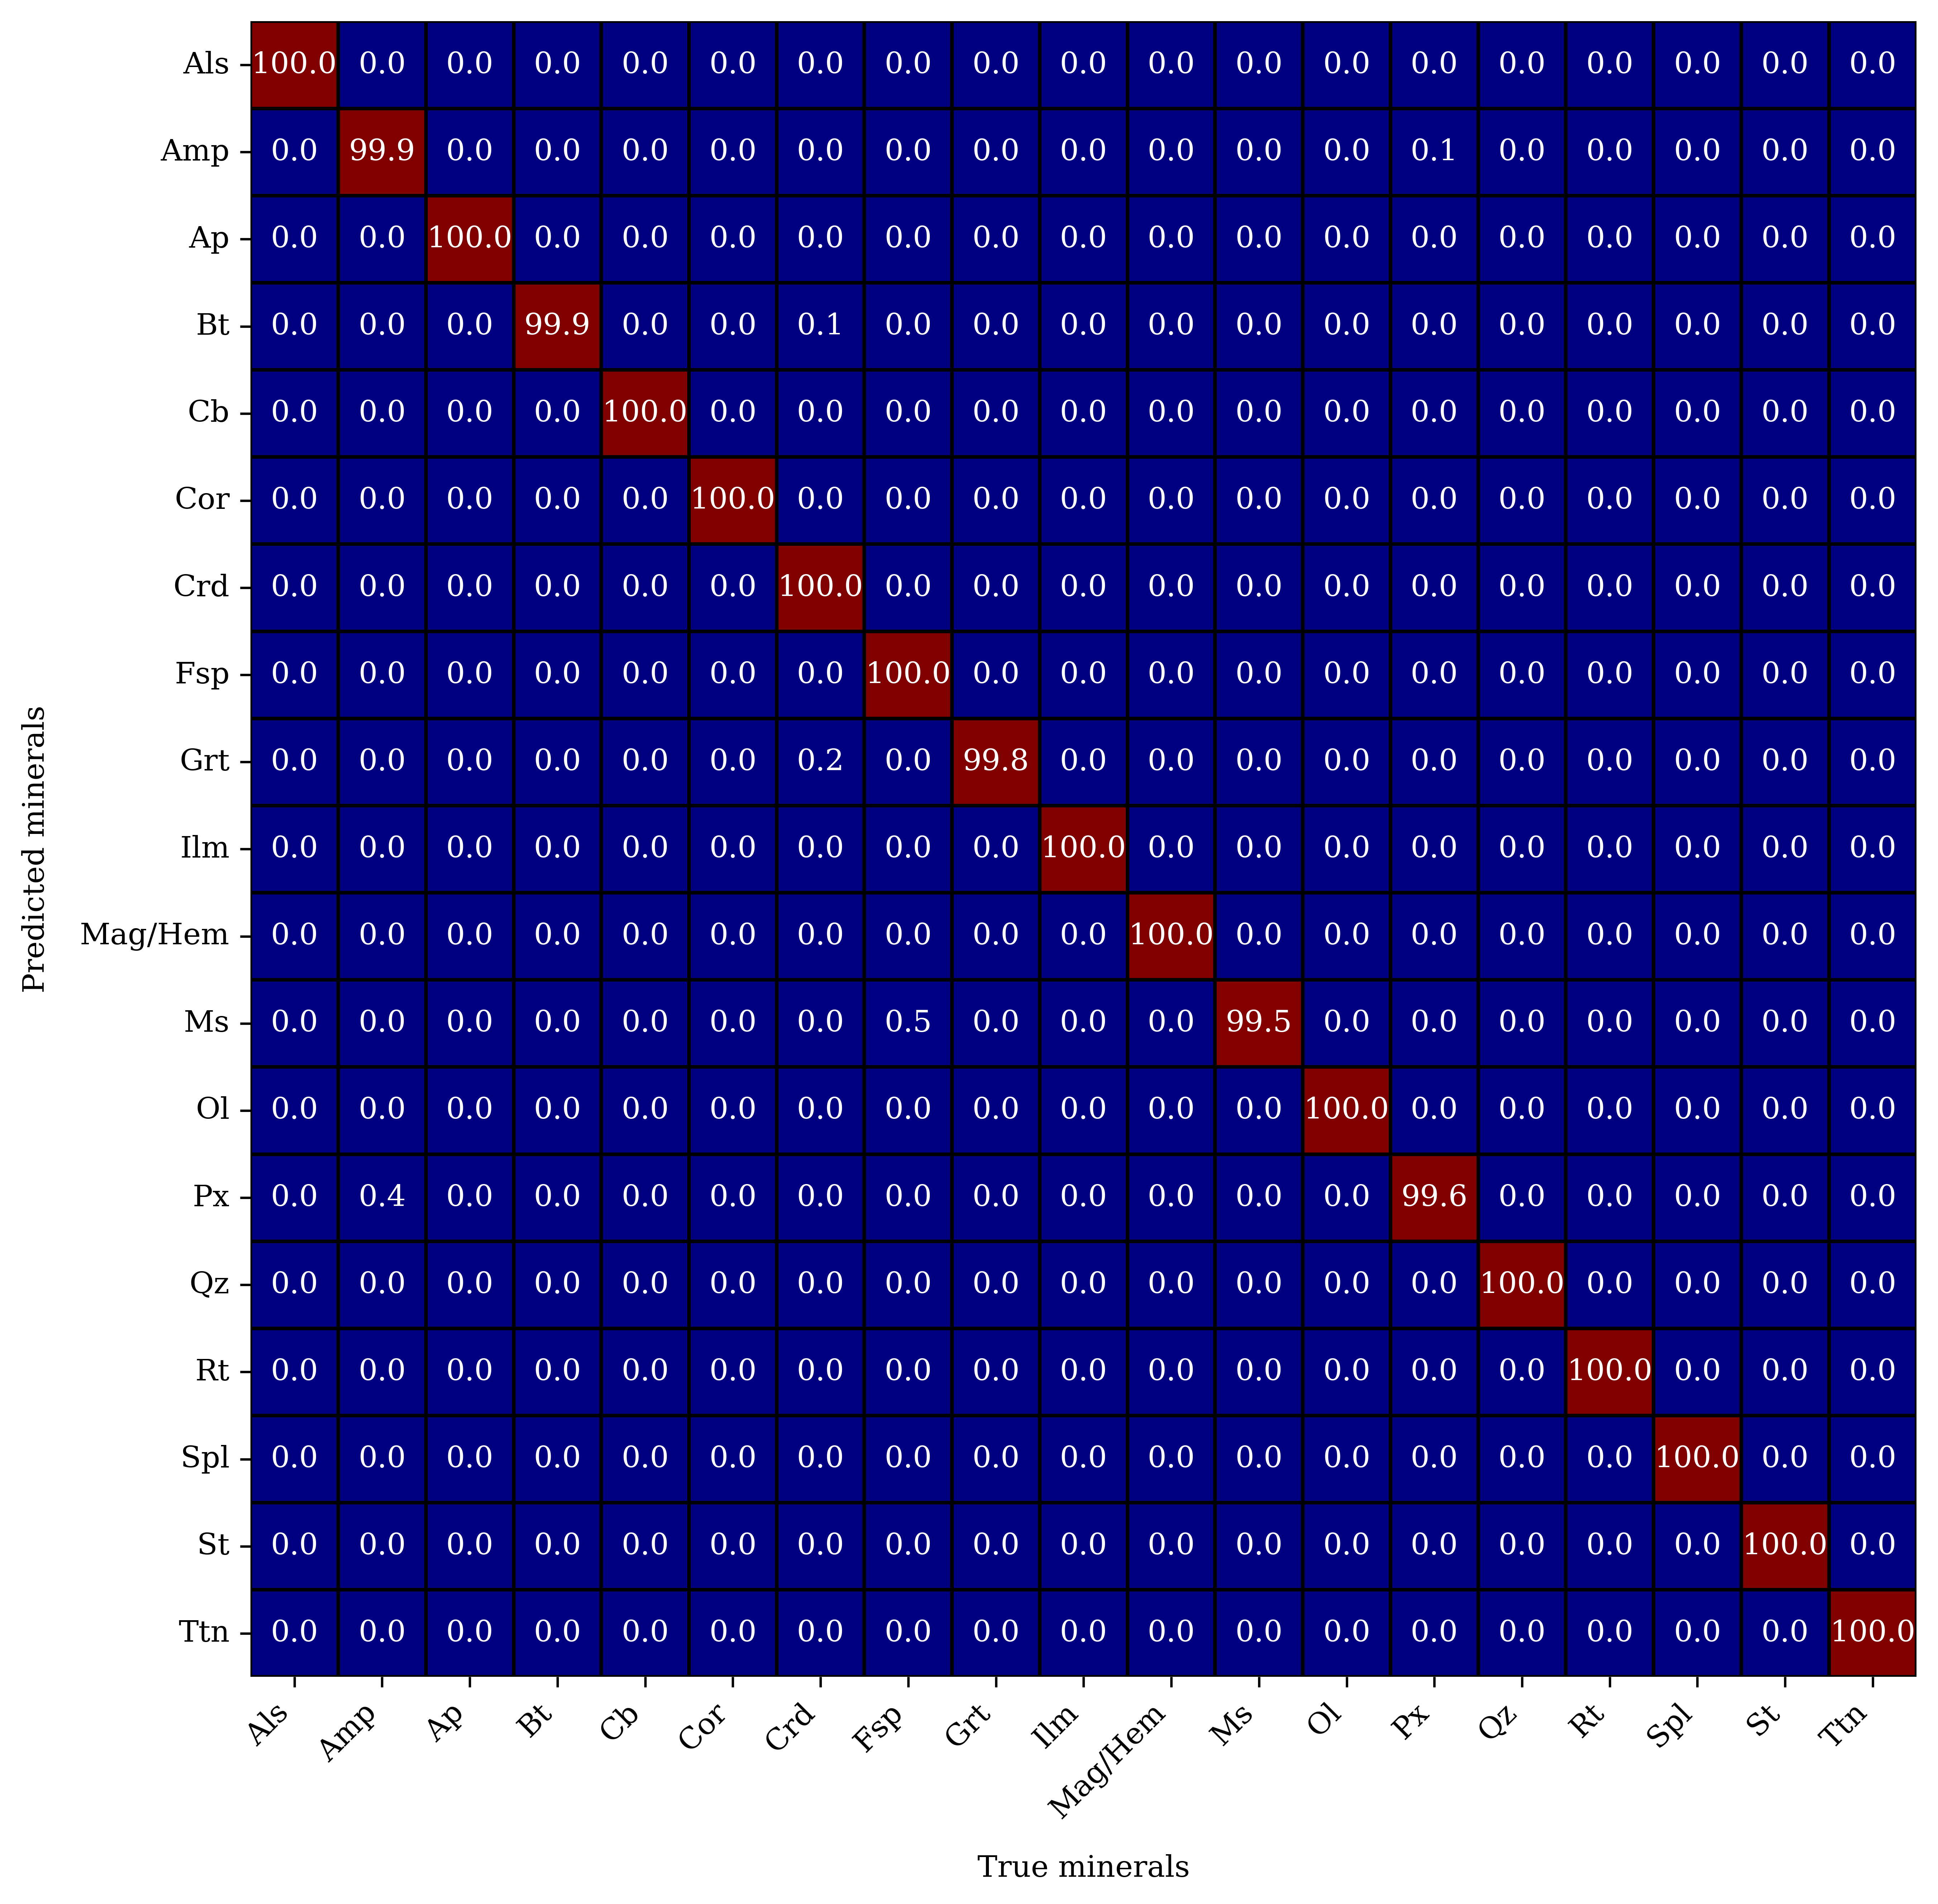

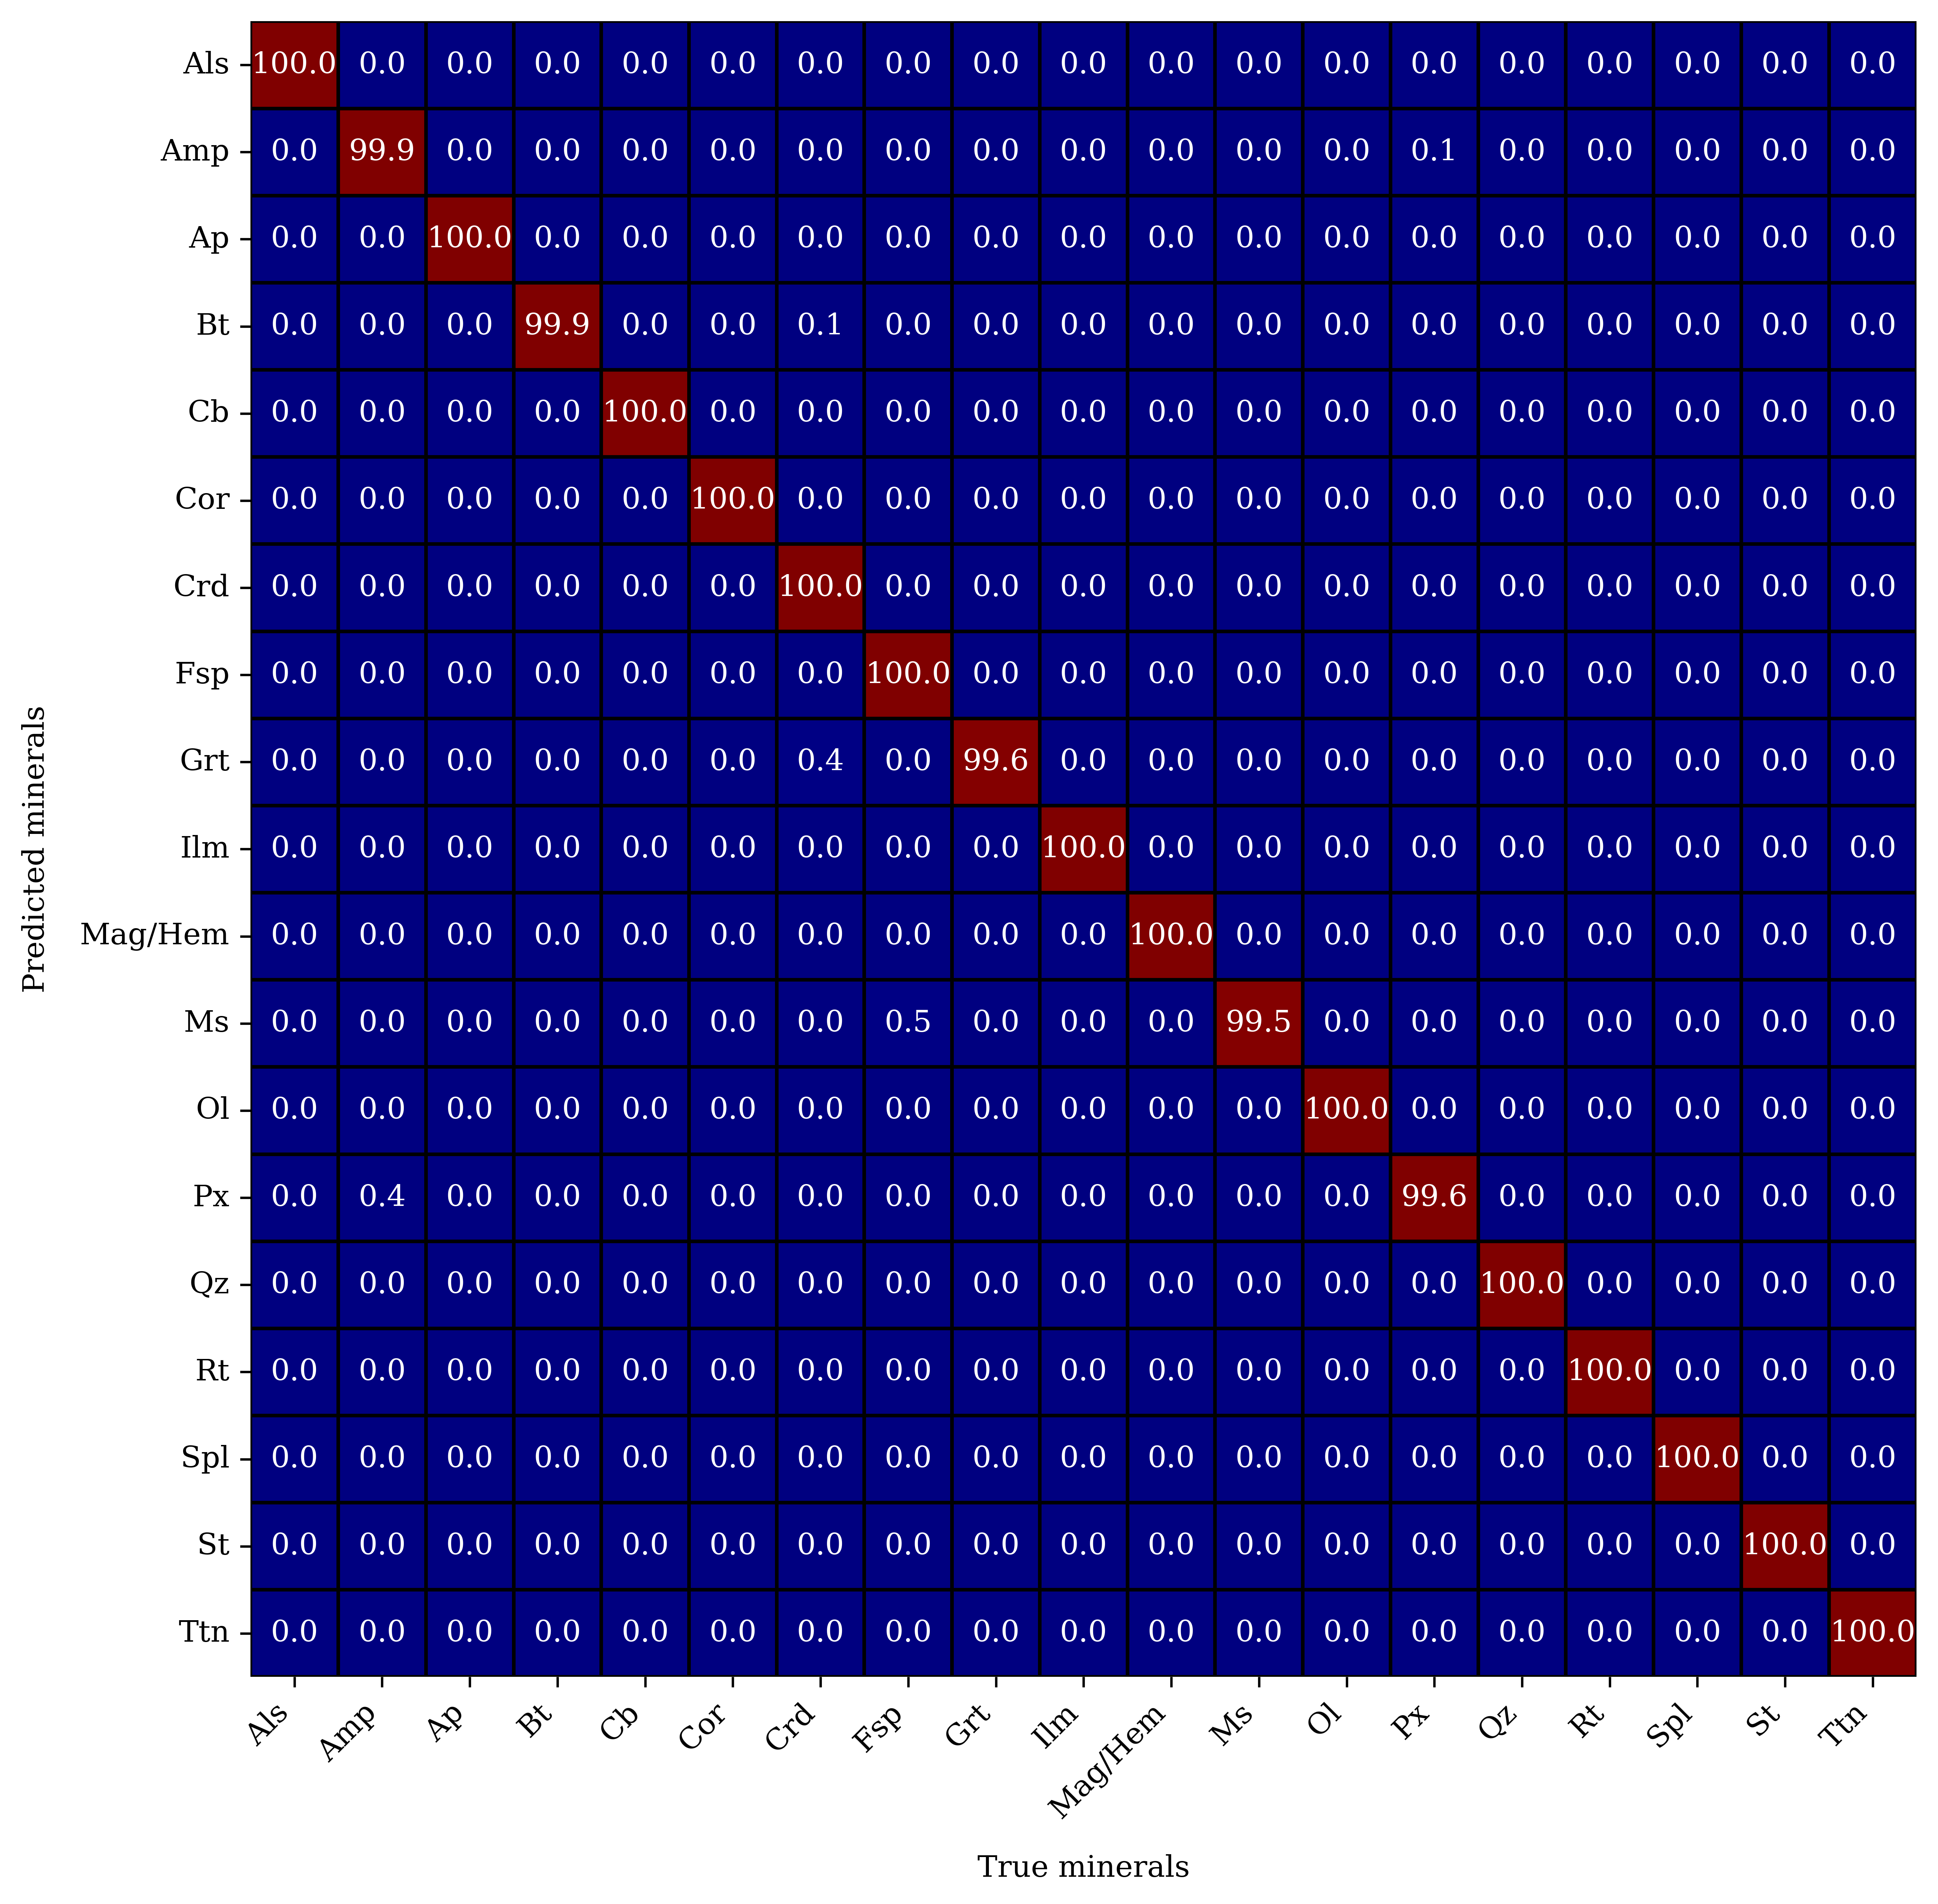

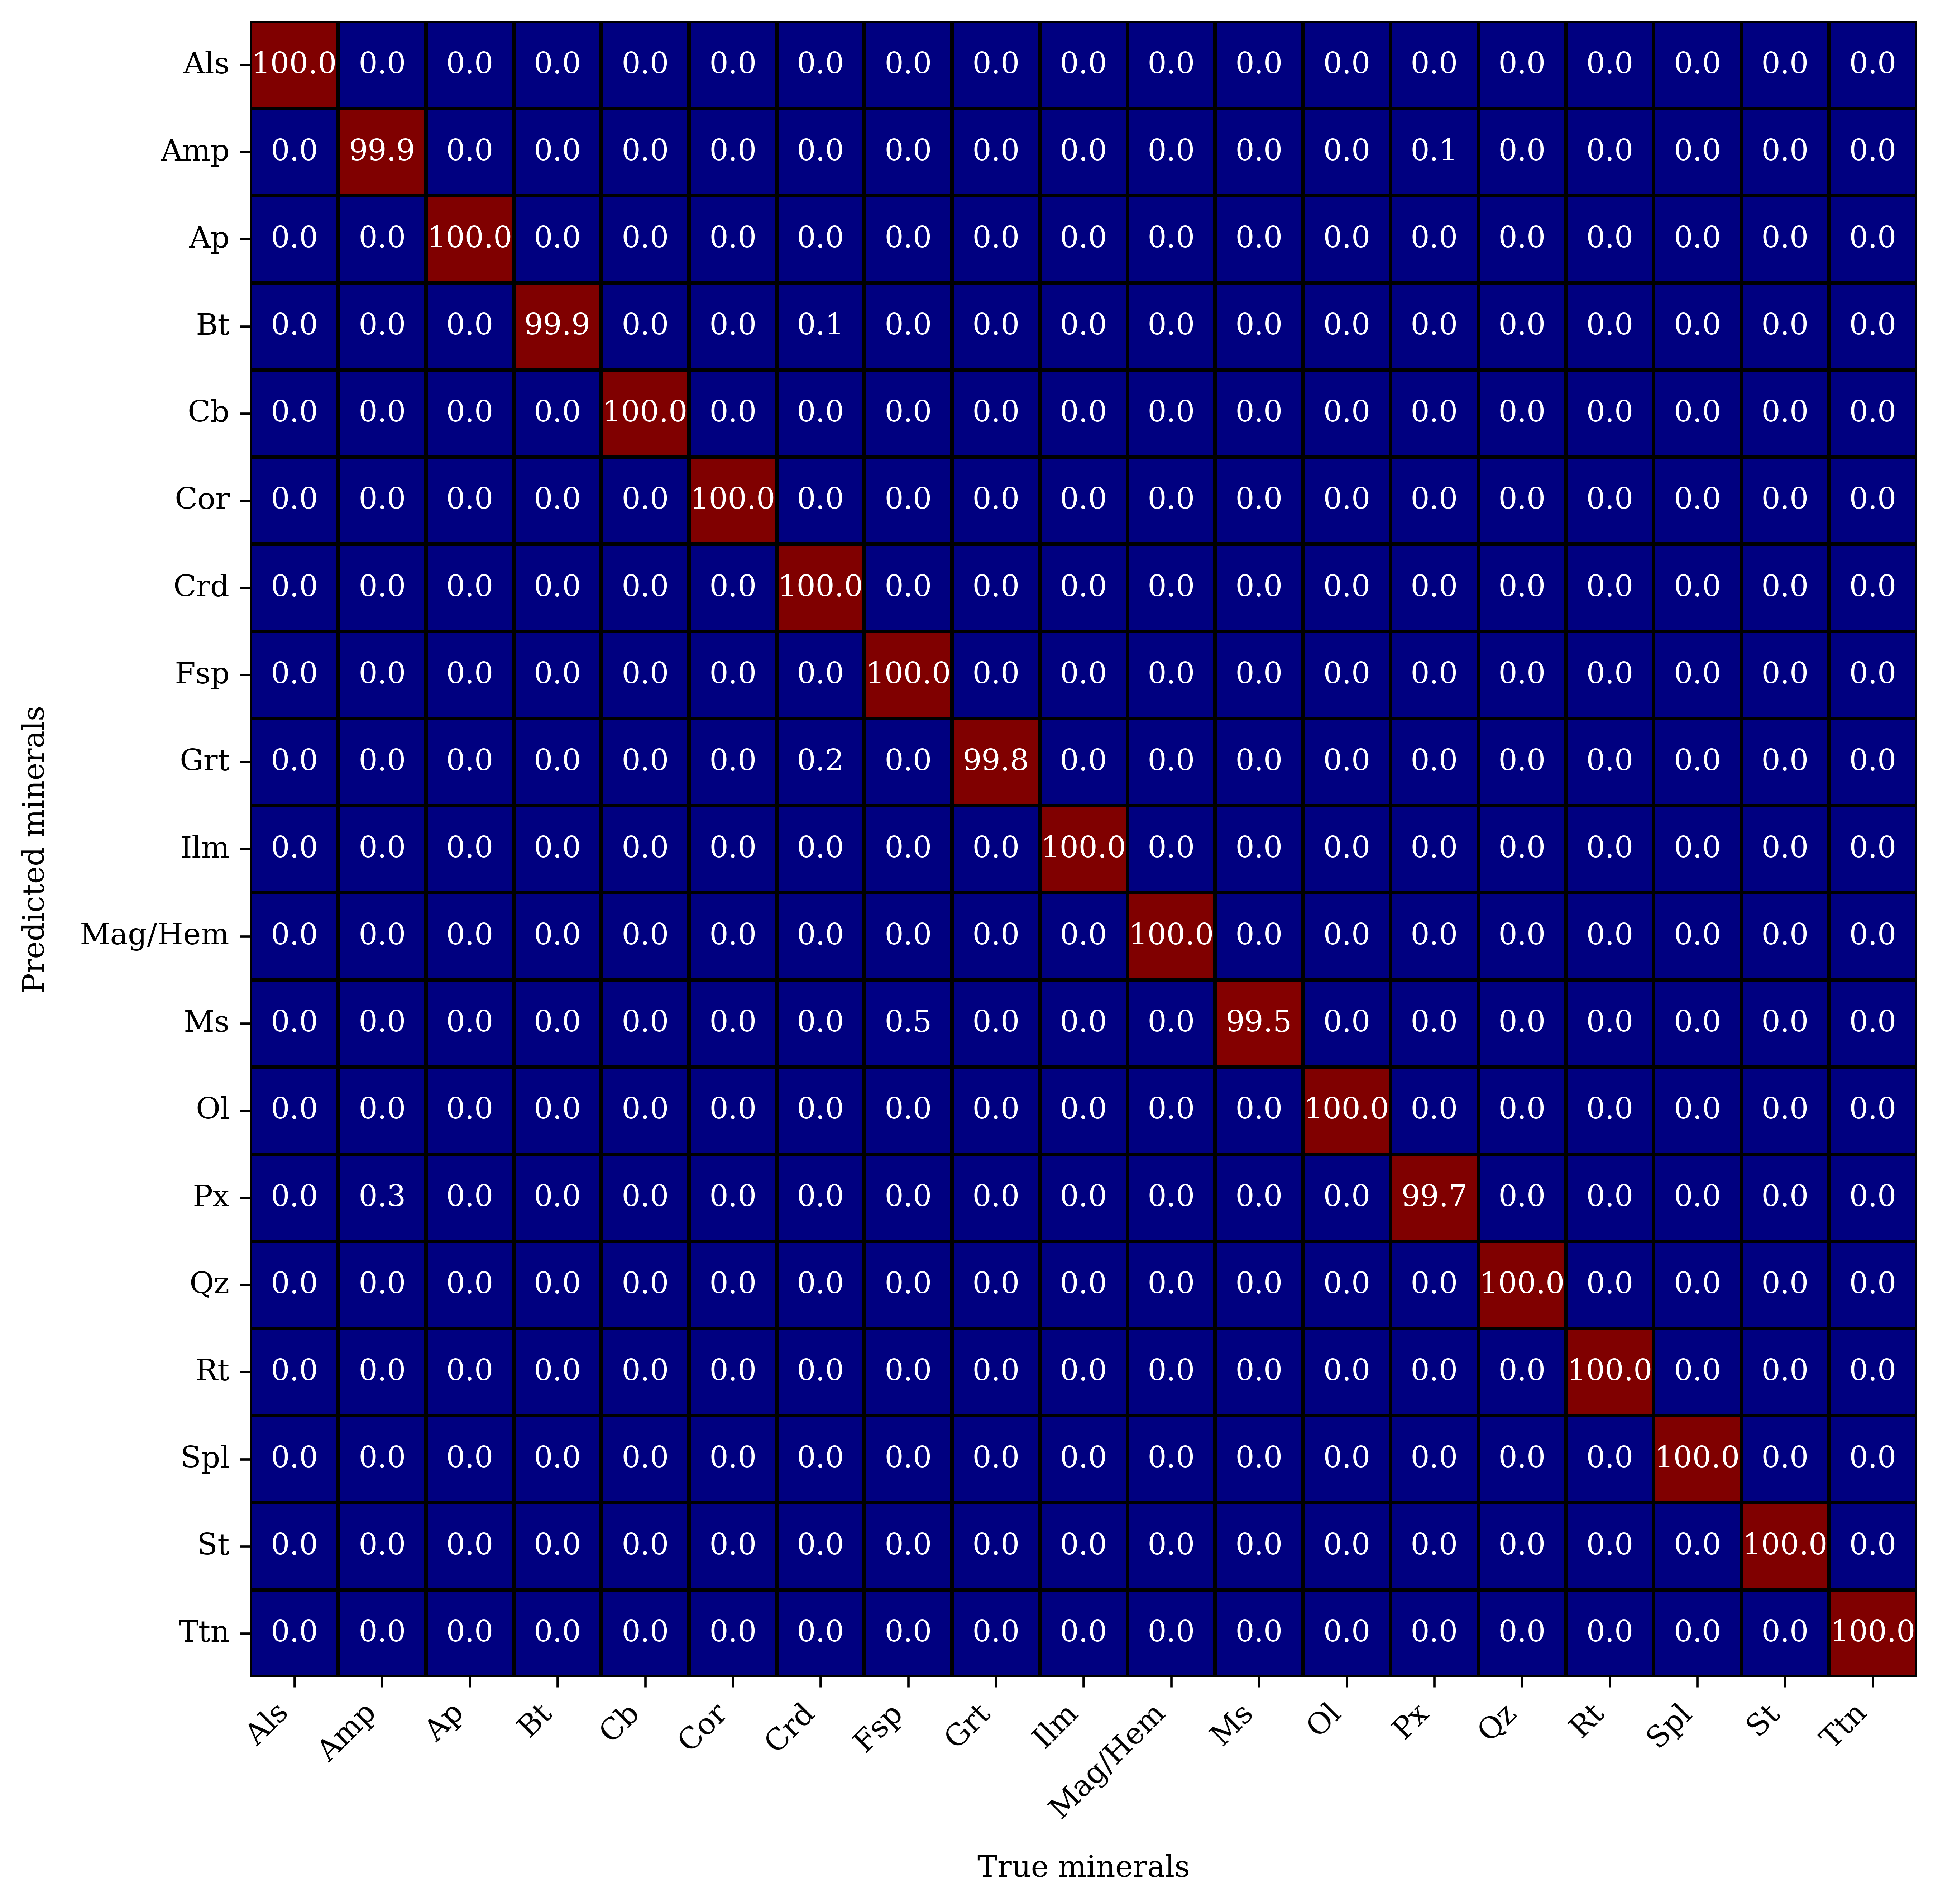

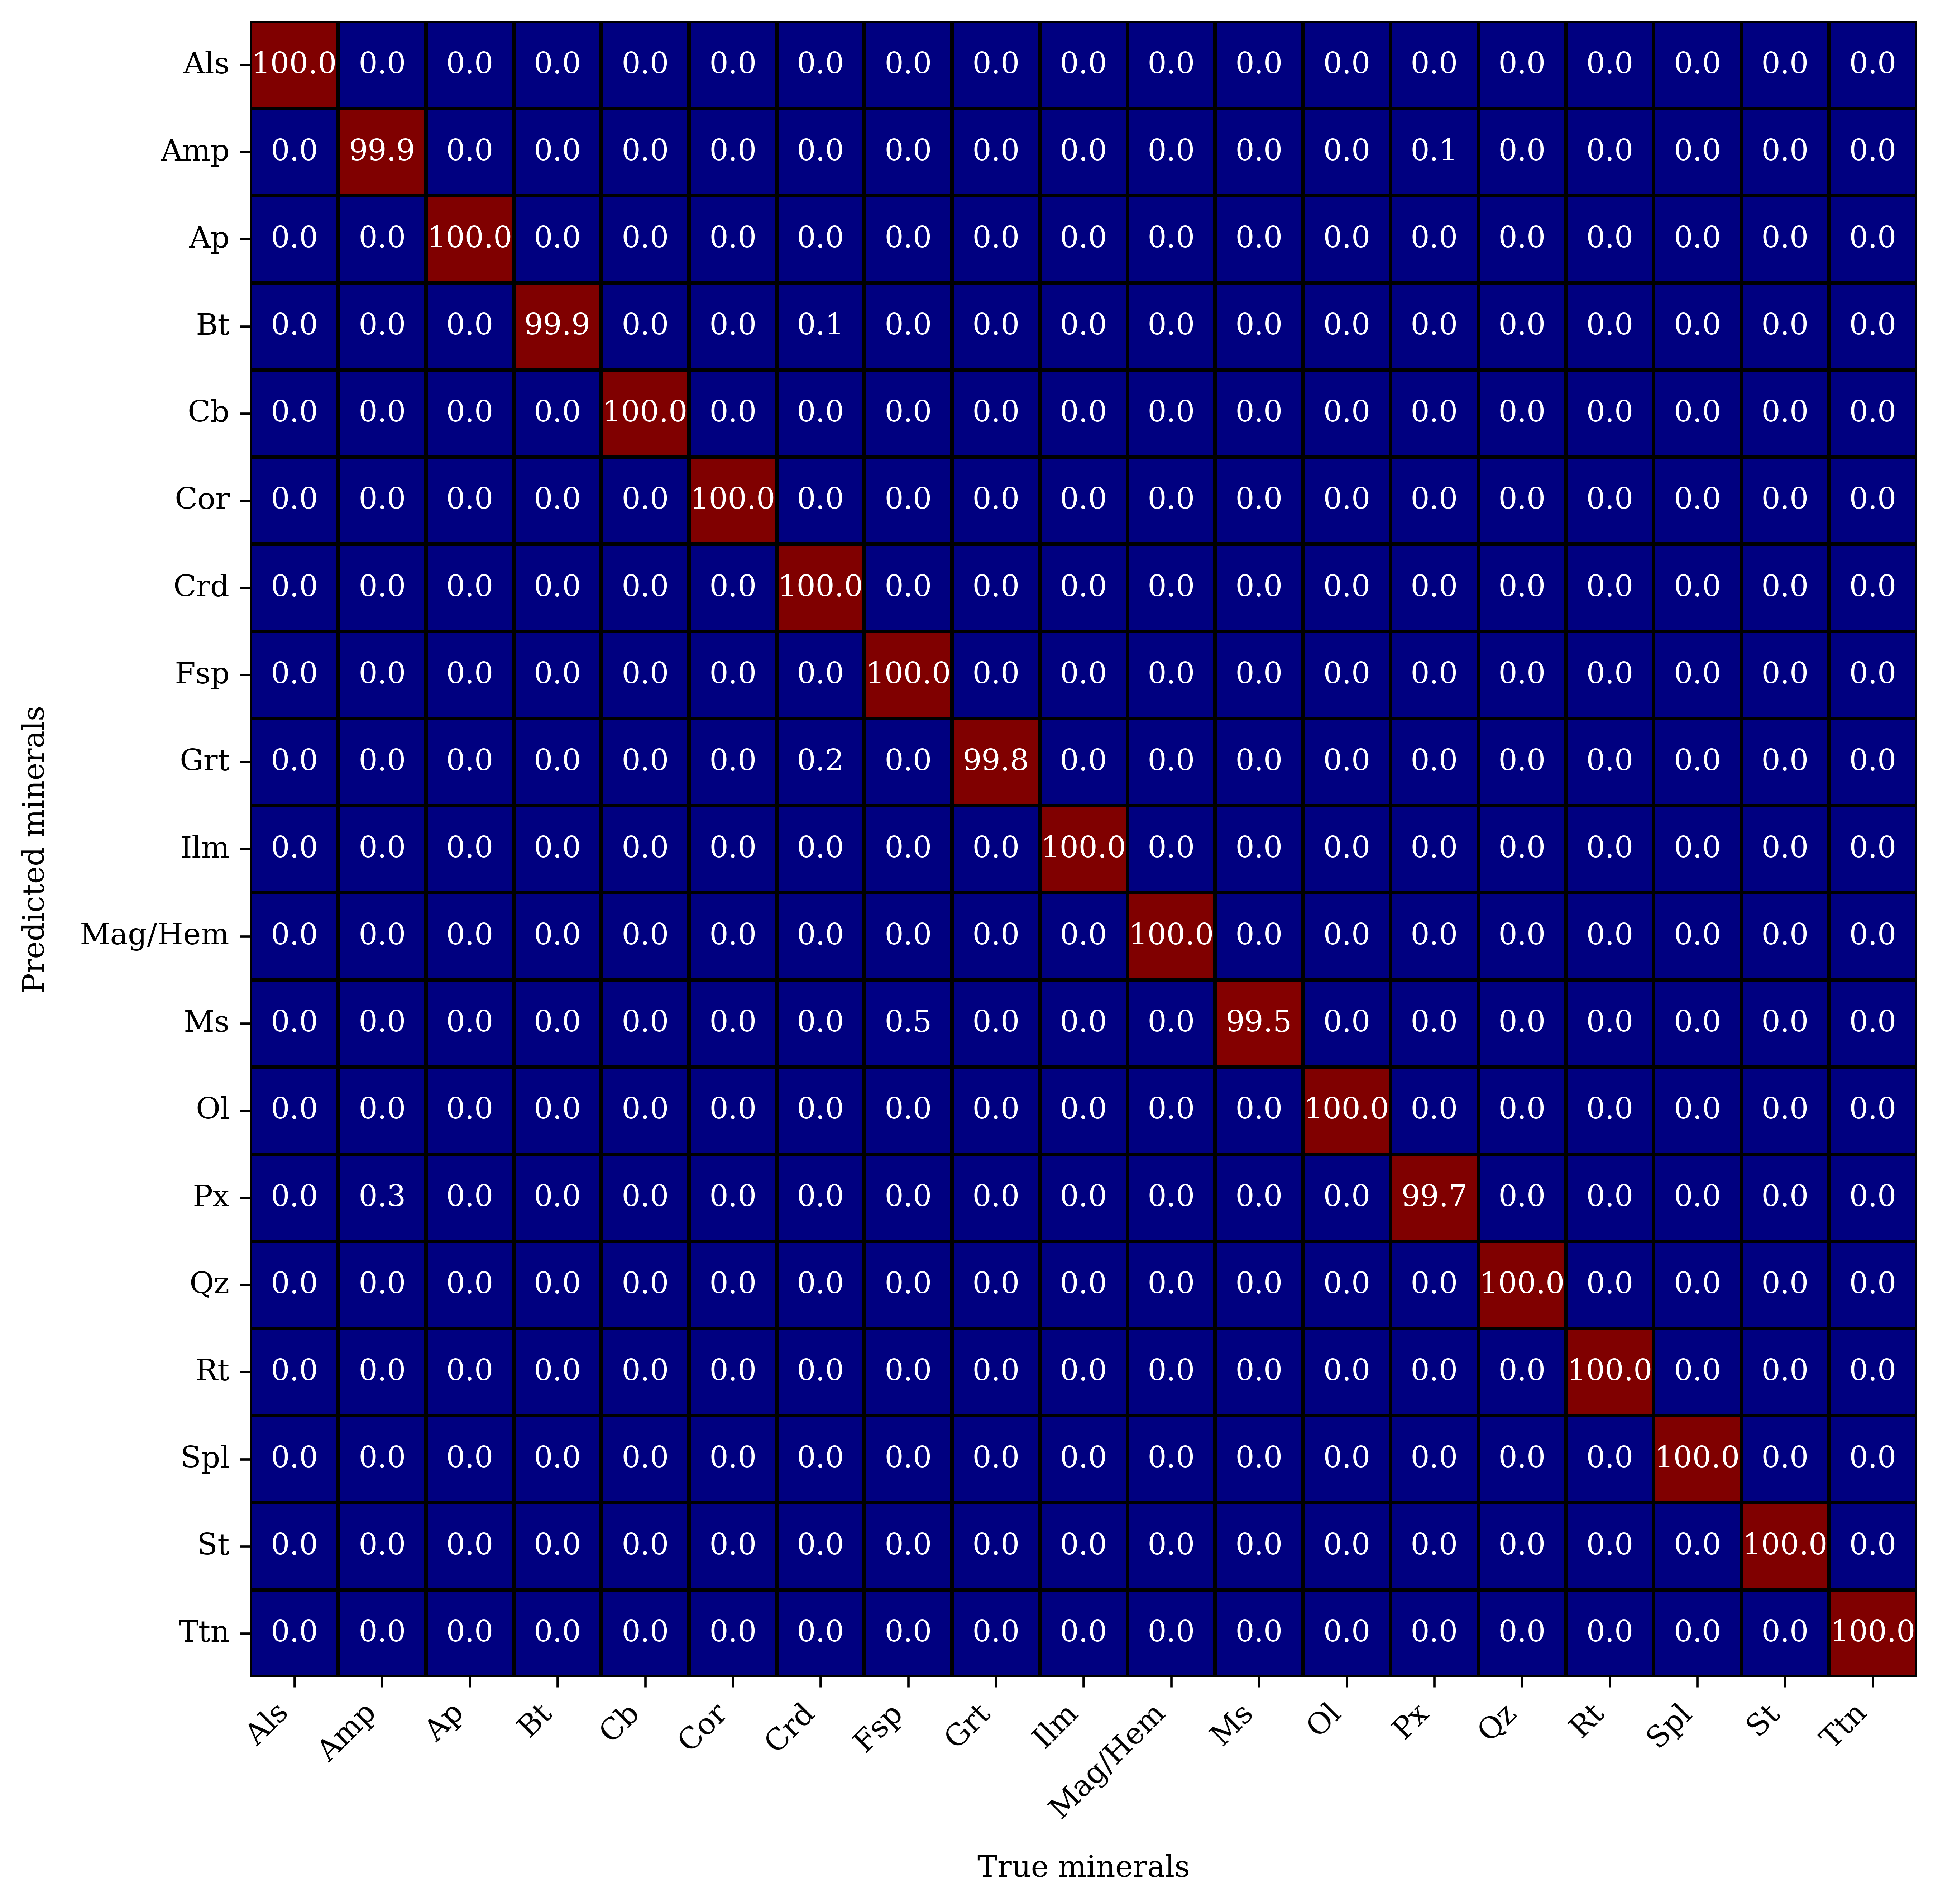

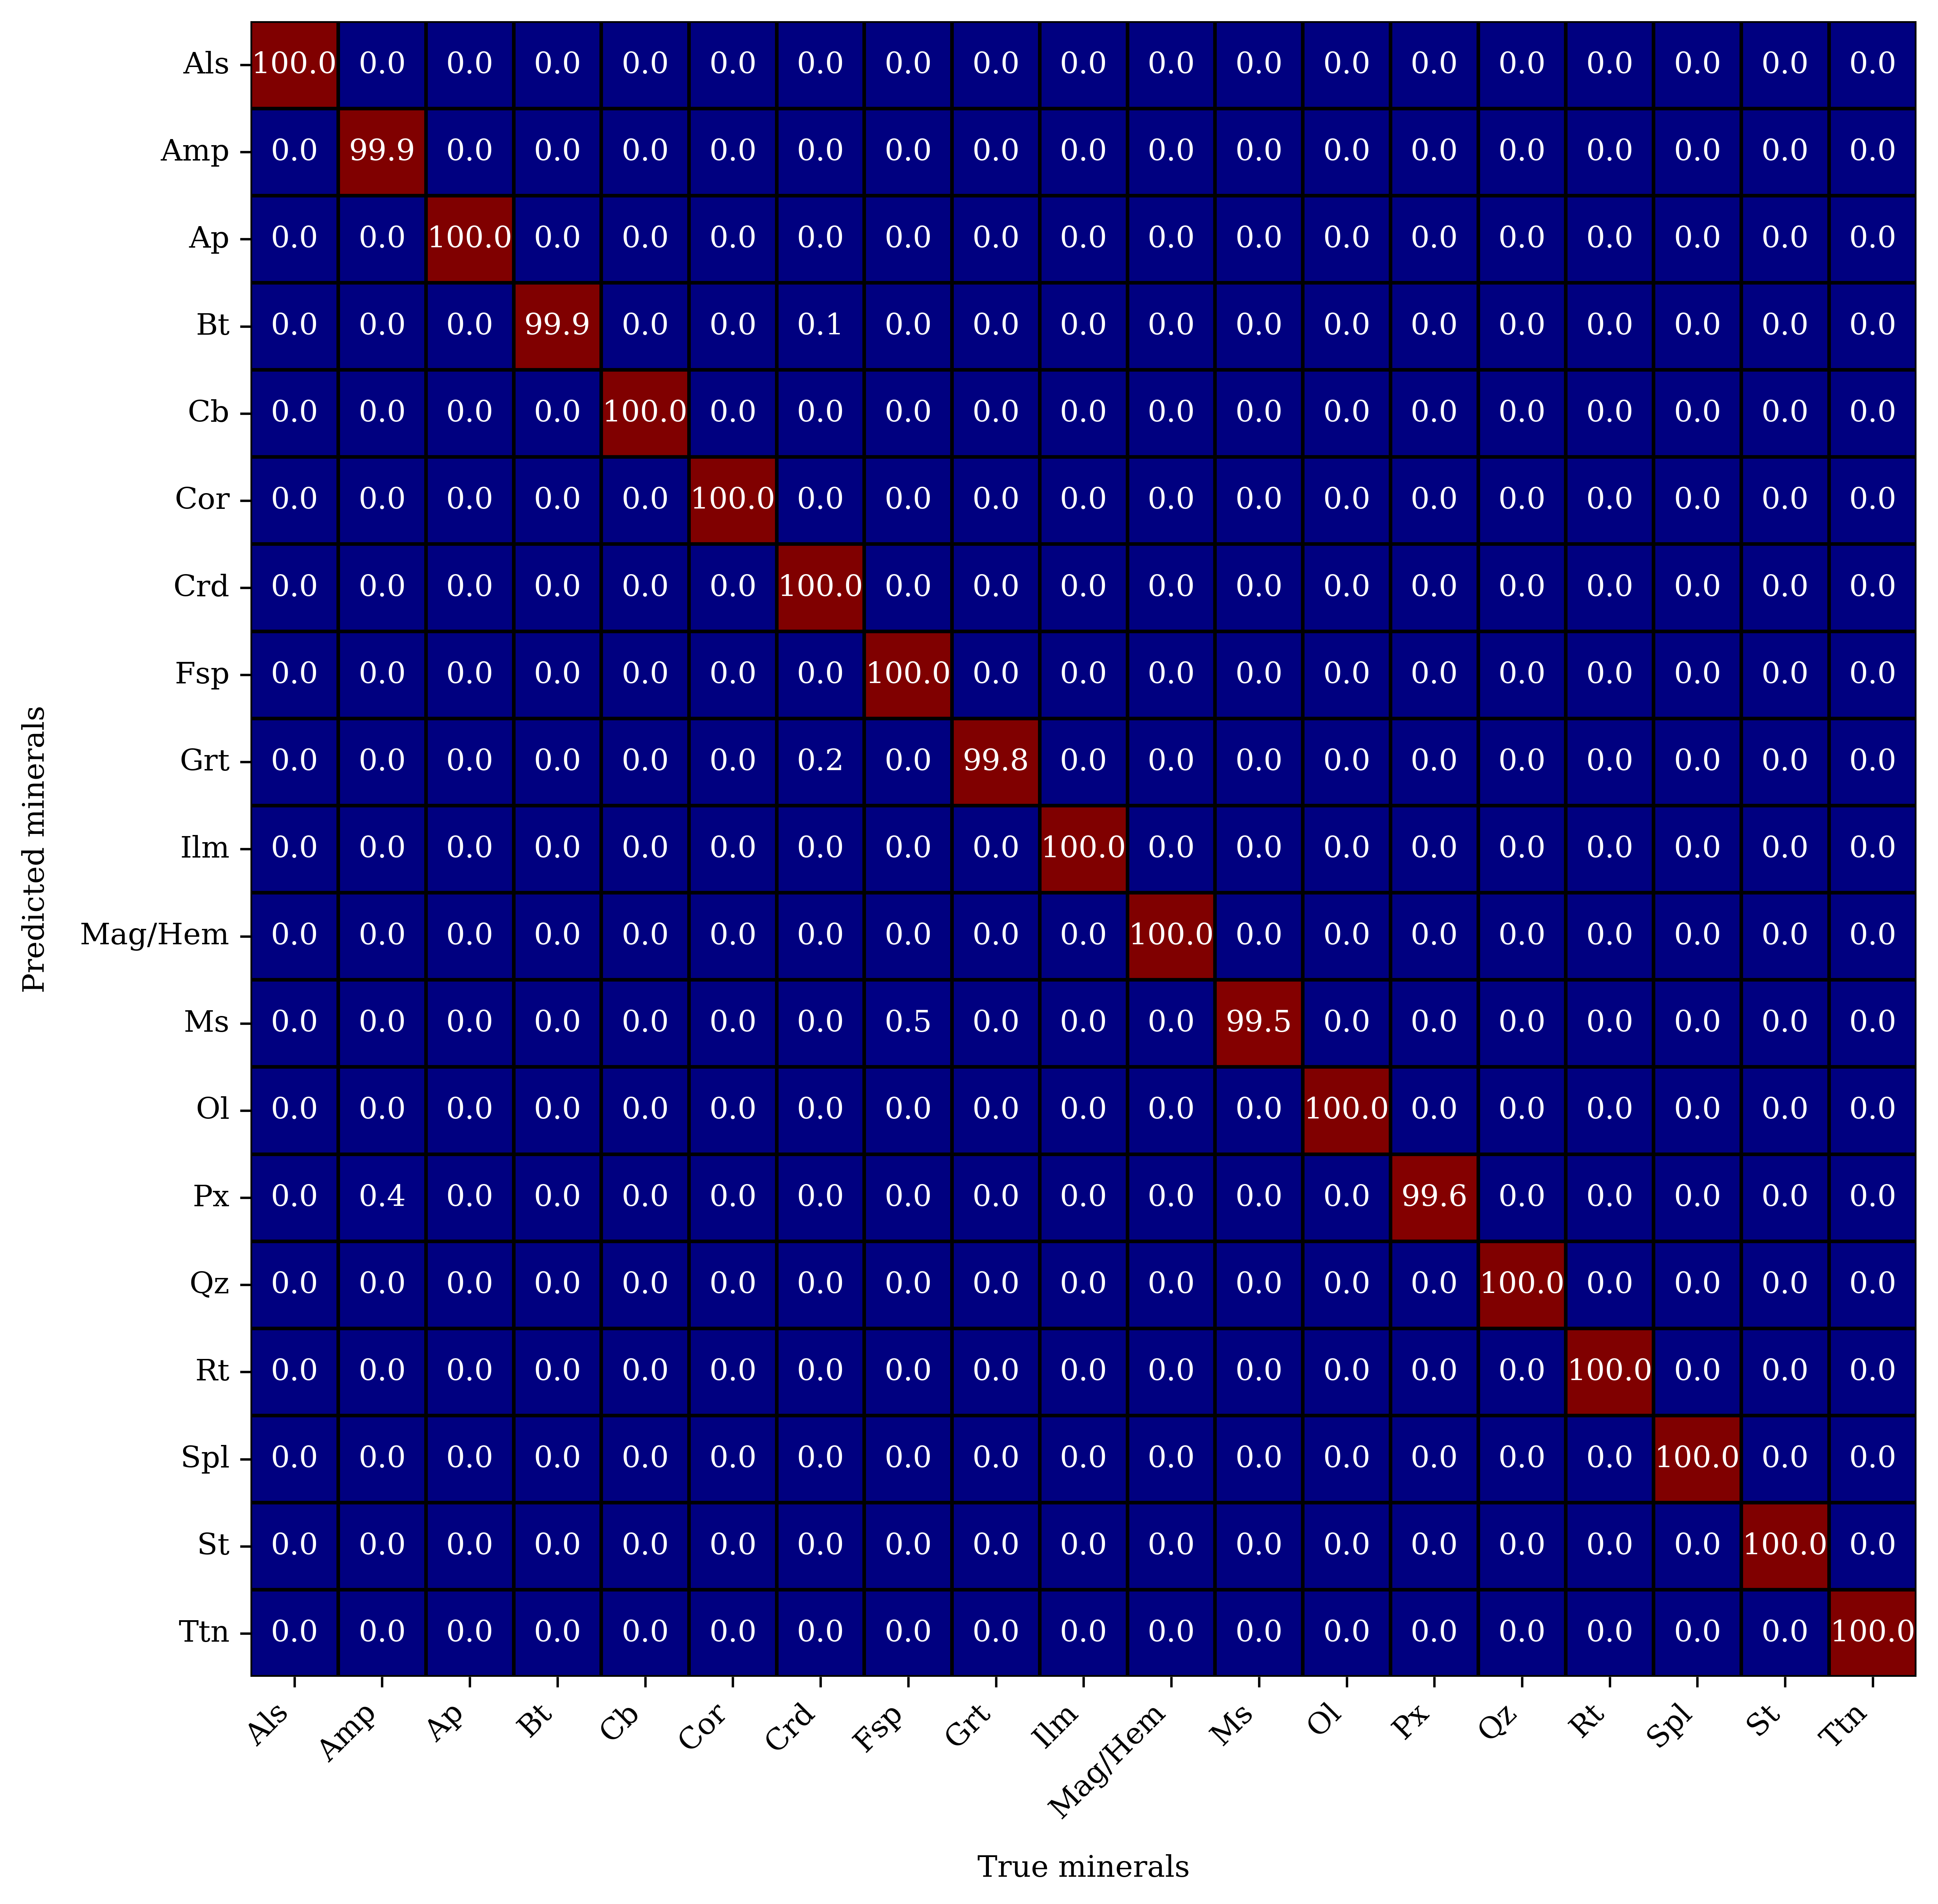

In [10]:
# data =pd.read_excel(file,header=0)
data = data1.copy()
data.loc[(data.Mineral == "opx") | (data.Mineral == "cpx"),"Mineral"] = "px"
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.iloc[:,:-1])

labeler = LabelEncoder()
target = labeler.fit_transform(data['Mineral'])

splitter = StratifiedShuffleSplit(n_splits=2,test_size=testsize,random_state=2)
split, split1 = splitter.split(data_scaled, target)
train_data = data_scaled[split1[0],:]
train_label = target[split1[0]]
test_data = data_scaled[split1[1],:]
test_label = target[split1[1]]

for i in range(5,11):
    
    print(f"\nTesting for PCA (n={i}) transformed input data\n")
    data_scaled = data_scaled.copy()
    pca = PCA(n_components=i,svd_solver="full")
    pca_normalized_data = pca.fit_transform(data_scaled)
    train_data = pca_normalized_data[split1[0],:]
    train_label = target[split1[0]]
    test_data = pca_normalized_data[split1[1],:]
    test_label = target[split1[1]]
    model.fit(train_data, train_label)
    pred_label = model.predict(test_data)
    # a = round(f1_score(test_label, pred_label, average=over_metrics),4)*100
    
    a = round(f1_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
    r = round(recall_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
    p = round(precision_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
    acc_table[0,i+3] = a
    precision_table[0,i+3] = p
    recall_table[0,i+3] = r
    print(round(a,2))
    # acc_table[0,i+3] = a
    cm = confusion_matrix(test_label, pred_label,normalize='true')*100
    cm = pd.DataFrame(cm,columns = labeler.classes_,index=labeler.classes_)
    plt.figure(figsize=figsize,dpi=600)
    sns.heatmap(cm, annot=True,cmap="jet",fmt='.1f',linewidths=lw,linecolor='black',cbar=False)
    plt.xticks(rotation=45,ha='right')
    plt.xlabel("True minerals",labelpad=10)
    plt.ylabel("Predicted minerals",labelpad=10)
    plt.savefig(f"KNN_C5(n={i}).pdf",bbox_inches='tight')
         
    for j in range(0,minerals-1):
        test_data1 = test_data[test_label==j]
        test_label1 = test_label[test_label==j]
        pred_label1 = model.predict(test_data1)
        a = round(f1_score(test_label1, pred_label1, average=sample_metrics),4)*100
        acc_table[j+1,i+3] = a
        
        a = round(f1_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
        r = round(recall_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
        p = round(precision_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
        acc_table[j+1,i+3] = a
        precision_table[j+1,i+3] = p
        recall_table[j+1,i+3] = r
        acc_table[j+1,i+3] = a
        name = labeler.inverse_transform([j])[0]
        print(f"{name}: accuracy: {a}")
data_scaled1 = pca.transform(data_scaled)
pred_label = model.predict(data_scaled1)
test_data_df = data.copy()
test_data_df['Pred'] = labeler.inverse_transform(pred_label)
test_data_df_mismatch = test_data_df[test_data_df['Mineral'] != test_data_df['Pred']]


In [62]:
l = ["Overall"]
l.extend([i for i in labeler.classes_])
# acc_table = pd.DataFrame(acc_table,
#                           columns=["Raw Input", "FeO+MnO+MgO combined", "FeO+MnO+MgO+CaO & Na2O+K2O combined", "FeO+MnO+MgO+CaO & Na2O+K2O+CaO combined", "PCA (n=1) transformed", "PCA (n=2) transformed", "PCA (n=3) transformed", "PCA (n=4) transformed", "PCA (n=5) transformed", "PCA (n=6) transformed", "PCA (n=7) transformed", "PCA (n=8) transformed"],
#                           index=["Overall", "Als", "Amp", "Ap", "Bt","Crd", 
#                                  "Fsp", "Grt", "Ilm","Mag", 'Ms','Ol','Pg',
#                                  'Px',"Qz",'Rt', 'Spl', 'St', 'Ttn'])
acc_table = pd.DataFrame(acc_table,
                          columns=["Raw Input", "FeO+MnO+MgO combined", "FeO+MnO+MgO & Na2O+K2O combined", "FeO+MnO+MgO+CaO & Na2O+K2O+CaO combined", "PCA (n=1) transformed", "PCA (n=2) transformed", "PCA (n=3) transformed", "PCA (n=4) transformed", "PCA (n=5) transformed", "PCA (n=6) transformed", "PCA (n=7) transformed", "PCA (n=8) transformed", "PCA (n=9) transformed", "PCA (n=10) transformed"],
                          index=l)
recall_table = pd.DataFrame(recall_table,
                          columns=["Raw Input", "FeO+MnO+MgO combined", "FeO+MnO+MgO & Na2O+K2O combined", "FeO+MnO+MgO+CaO & Na2O+K2O+CaO combined", "PCA (n=1) transformed", "PCA (n=2) transformed", "PCA (n=3) transformed", "PCA (n=4) transformed", "PCA (n=5) transformed", "PCA (n=6) transformed", "PCA (n=7) transformed", "PCA (n=8) transformed", "PCA (n=9) transformed", "PCA (n=10) transformed"],
                          index=l)

precision_table = pd.DataFrame(precision_table,
                          columns=["Raw Input", "FeO+MnO+MgO combined", "FeO+MnO+MgO & Na2O+K2O combined", "FeO+MnO+MgO+CaO & Na2O+K2O+CaO combined", "PCA (n=1) transformed", "PCA (n=2) transformed", "PCA (n=3) transformed", "PCA (n=4) transformed", "PCA (n=5) transformed", "PCA (n=6) transformed", "PCA (n=7) transformed", "PCA (n=8) transformed", "PCA (n=9) transformed", "PCA (n=10) transformed"],
                          index=l)

In [63]:
acc_table

,Raw Input,FeO+MnO+MgO combined,FeO+MnO+MgO & Na2O+K2O combined,FeO+MnO+MgO+CaO & Na2O+K2O+CaO combined,PCA (n=1) transformed,PCA (n=2) transformed,PCA (n=3) transformed,PCA (n=4) transformed,PCA (n=5) transformed,PCA (n=6) transformed,PCA (n=7) transformed,PCA (n=8) transformed,PCA (n=9) transformed,PCA (n=10) transformed
Overall,99.90,99.95,99.96,99.96,0.0,0.0,0.0,0.0,99.91,99.90,0.0,0.0,0.0,0.0
Als,100.00,100.00,100.00,100.00,0.0,0.0,0.0,0.0,100.00,100.00,0.0,0.0,0.0,0.0
Amp,99.96,99.98,99.98,100.00,0.0,0.0,0.0,0.0,99.96,99.96,0.0,0.0,0.0,0.0
Ap,100.00,100.00,100.00,100.00,0.0,0.0,0.0,0.0,100.00,100.00,0.0,0.0,0.0,0.0
Bt,99.97,100.00,100.00,100.00,0.0,0.0,0.0,0.0,99.95,99.95,0.0,0.0,0.0,0.0
Cb,100.00,100.00,100.00,100.00,0.0,0.0,0.0,0.0,100.00,100.00,0.0,0.0,0.0,0.0
Cor,100.00,100.00,100.00,100.00,0.0,0.0,0.0,0.0,100.00,100.00,0.0,0.0,0.0,0.0
Crd,100.00,100.00,100.00,100.00,0.0,0.0,0.0,0.0,100.00,100.00,0.0,0.0,0.0,0.0
Fsp,100.00,100.00,100.00,100.00,0.0,0.0,0.0,0.0,100.00,100.00,0.0,0.0,0.0,0.0
Grt,99.91,100.00,100.00,100.00,0.0,0.0,0.0,0.0,100.00,99.91,0.0,0.0,0.0,0.0


In [64]:
precision_table

,Raw Input,FeO+MnO+MgO combined,FeO+MnO+MgO & Na2O+K2O combined,FeO+MnO+MgO+CaO & Na2O+K2O+CaO combined,PCA (n=1) transformed,PCA (n=2) transformed,PCA (n=3) transformed,PCA (n=4) transformed,PCA (n=5) transformed,PCA (n=6) transformed,PCA (n=7) transformed,PCA (n=8) transformed,PCA (n=9) transformed,PCA (n=10) transformed
Overall,99.9,99.95,99.96,99.96,0.0,0.0,0.0,0.0,99.91,99.9,0.0,0.0,0.0,0.0
Als,100.0,100.00,100.00,100.00,0.0,0.0,0.0,0.0,100.00,100.0,0.0,0.0,0.0,0.0
Amp,100.0,100.00,100.00,100.00,0.0,0.0,0.0,0.0,100.00,100.0,0.0,0.0,0.0,0.0
Ap,100.0,100.00,100.00,100.00,0.0,0.0,0.0,0.0,100.00,100.0,0.0,0.0,0.0,0.0
Bt,100.0,100.00,100.00,100.00,0.0,0.0,0.0,0.0,100.00,100.0,0.0,0.0,0.0,0.0
Cb,100.0,100.00,100.00,100.00,0.0,0.0,0.0,0.0,100.00,100.0,0.0,0.0,0.0,0.0
Cor,100.0,100.00,100.00,100.00,0.0,0.0,0.0,0.0,100.00,100.0,0.0,0.0,0.0,0.0
Crd,100.0,100.00,100.00,100.00,0.0,0.0,0.0,0.0,100.00,100.0,0.0,0.0,0.0,0.0
Fsp,100.0,100.00,100.00,100.00,0.0,0.0,0.0,0.0,100.00,100.0,0.0,0.0,0.0,0.0
Grt,100.0,100.00,100.00,100.00,0.0,0.0,0.0,0.0,100.00,100.0,0.0,0.0,0.0,0.0


In [65]:
recall_table

,Raw Input,FeO+MnO+MgO combined,FeO+MnO+MgO & Na2O+K2O combined,FeO+MnO+MgO+CaO & Na2O+K2O+CaO combined,PCA (n=1) transformed,PCA (n=2) transformed,PCA (n=3) transformed,PCA (n=4) transformed,PCA (n=5) transformed,PCA (n=6) transformed,PCA (n=7) transformed,PCA (n=8) transformed,PCA (n=9) transformed,PCA (n=10) transformed
Overall,99.90,99.95,99.96,99.96,0.0,0.0,0.0,0.0,99.91,99.90,0.0,0.0,0.0,0.0
Als,100.00,100.00,100.00,100.00,0.0,0.0,0.0,0.0,100.00,100.00,0.0,0.0,0.0,0.0
Amp,99.93,99.96,99.96,100.00,0.0,0.0,0.0,0.0,99.93,99.93,0.0,0.0,0.0,0.0
Ap,100.00,100.00,100.00,100.00,0.0,0.0,0.0,0.0,100.00,100.00,0.0,0.0,0.0,0.0
Bt,99.95,100.00,100.00,100.00,0.0,0.0,0.0,0.0,99.89,99.89,0.0,0.0,0.0,0.0
Cb,100.00,100.00,100.00,100.00,0.0,0.0,0.0,0.0,100.00,100.00,0.0,0.0,0.0,0.0
Cor,100.00,100.00,100.00,100.00,0.0,0.0,0.0,0.0,100.00,100.00,0.0,0.0,0.0,0.0
Crd,100.00,100.00,100.00,100.00,0.0,0.0,0.0,0.0,100.00,100.00,0.0,0.0,0.0,0.0
Fsp,100.00,100.00,100.00,100.00,0.0,0.0,0.0,0.0,100.00,100.00,0.0,0.0,0.0,0.0
Grt,99.82,100.00,100.00,100.00,0.0,0.0,0.0,0.0,100.00,99.82,0.0,0.0,0.0,0.0


In [22]:
path = "/home/avi/Documents/Research/Mineral identifier ann IISER Mohali/Additional machine learning algos/KNN/"

acc_table.to_excel(path+r"F1-score Accuracy report for KNN_new.xlsx")
# acc_table.to_excel(r"/home/avi/Documents/Research/Mineral identifier ann IISER Mohali/Additional machine learning algos/SVM/F1-score Accuracy report for SVM_withoutamph.xlsx")
recall_table.to_excel(path+r"Recall-score Accuracy report for KNN_new.xlsx")
precision_table.to_excel(path+r"Precision-score Accuracy report for KNN.xlsx")

In [23]:
model.algorithm

'brute'

In [24]:
model.score

<bound method ClassifierMixin.score of KNeighborsClassifier(algorithm='brute', n_neighbors=3, weights='distance')>

In [25]:
import joblib

In [26]:
# joblib.dump(model,"model_01042024.pkl")
# joblib.dump(scaler,"scaler_01042024.pkl")
# joblib.dump(labeler,"labelencoder_01042024.pkl")

In [90]:
labeler.

array(['Als', 'Amp', 'Ap', 'Bt', 'Cb', 'Cor', 'Crd', 'Fsp', 'Grt', 'Ilm',
       'Mag/Hem', 'Ms', 'Ol', 'Px', 'Qz', 'Rt', 'Spl', 'St', 'Ttn'],
      dtype=object)

In [16]:
pca.explained_variance_ratio_

array([0.20349887, 0.15404702, 0.12794202, 0.1069709 , 0.09784201,
       0.09052353])

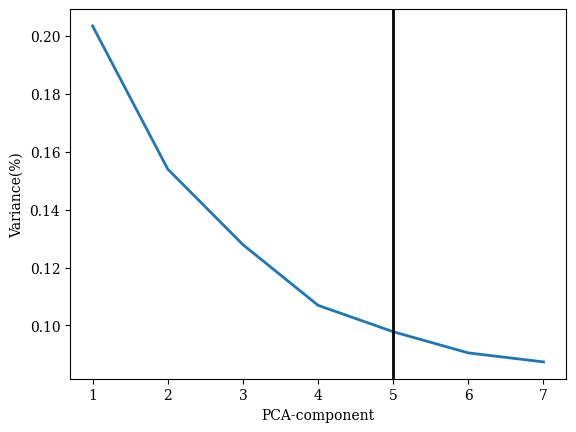

In [31]:
plt.rc('lines',lw=2,color='k')
plt.plot(np.arange(1,8,1),pca.explained_variance_ratio_[:7])
plt.xlabel('PCA-component')
plt.ylabel('Variance(%)')
plt.axvline(x=5,color='k')

In [33]:
np.round(np.cumsum(pca.explained_variance_ratio_),2)

array([0.2 , 0.36, 0.49, 0.59, 0.69, 0.78, 0.87, 0.94, 0.99, 1.  ])

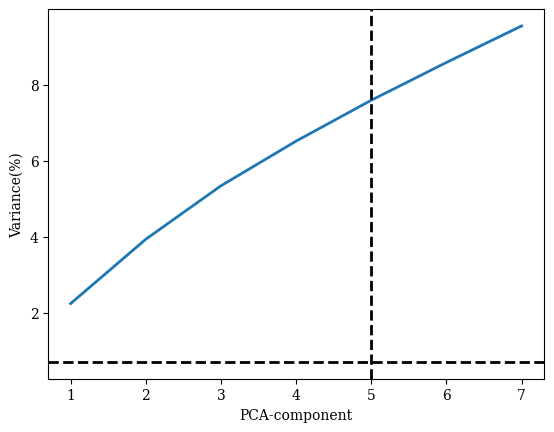

In [47]:
plt.rc('lines',lw=2,color='k')
plt.plot(np.arange(1,8,1),np.cumsum(pca.explained_variance_[:7]))
plt.xlabel('PCA-component')
plt.ylabel('Variance(%)')
plt.axvline(x=5,color='k',ls='--')
plt.axhline(y=.7,color='k',ls='--')

In [37]:
np.shape(data)

(47031, 12)

In [38]:
data

,SiO2,TiO2,Al2O3,FeO,MnO,MgO,CaO,Na2O,K2O,P2O5,CO2,Mineral
S No.,,,,,,,,,,,,
0,50.0,0.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Als
658,50.0,0.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Als
659,50.0,0.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Als
660,50.0,0.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Als
661,50.0,0.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Als
...,...,...,...,...,...,...,...,...,...,...,...,...
41956,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cor
41957,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cor
41958,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cor


In [59]:
np.round(pca.explained_variance_,3)

array([2.239, 1.695, 1.407, 1.177, 1.076, 0.996, 0.962, 0.812, 0.529,
       0.109])

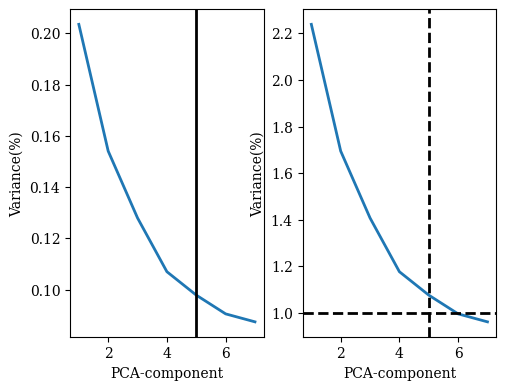

In [61]:
plt.figure(figsize=(5.5,4.25))
plt.subplot(121)
plt.rc('lines',lw=2,color='k')
plt.plot(np.arange(1,8,1),pca.explained_variance_ratio_[:7])
plt.xlabel('PCA-component')
plt.ylabel('Variance(%)')
plt.axvline(x=5,color='k')

plt.subplot(122)
plt.rc('lines',lw=2,color='k')
plt.plot(np.arange(1,8,1),pca.explained_variance_[:7])
plt.xlabel('PCA-component')
plt.ylabel('Variance(%)')
plt.axvline(x=5,color='k',ls='--')
plt.axhline(y=1,color='k',ls='--')
plt.savefig("D:/Research/Mineral identifier ann IISER Mohali/ms and reference papers/AmMin Submission and Reviews/Revision 1/PCA_scree_plots.pdf",bbox_inches='tight')

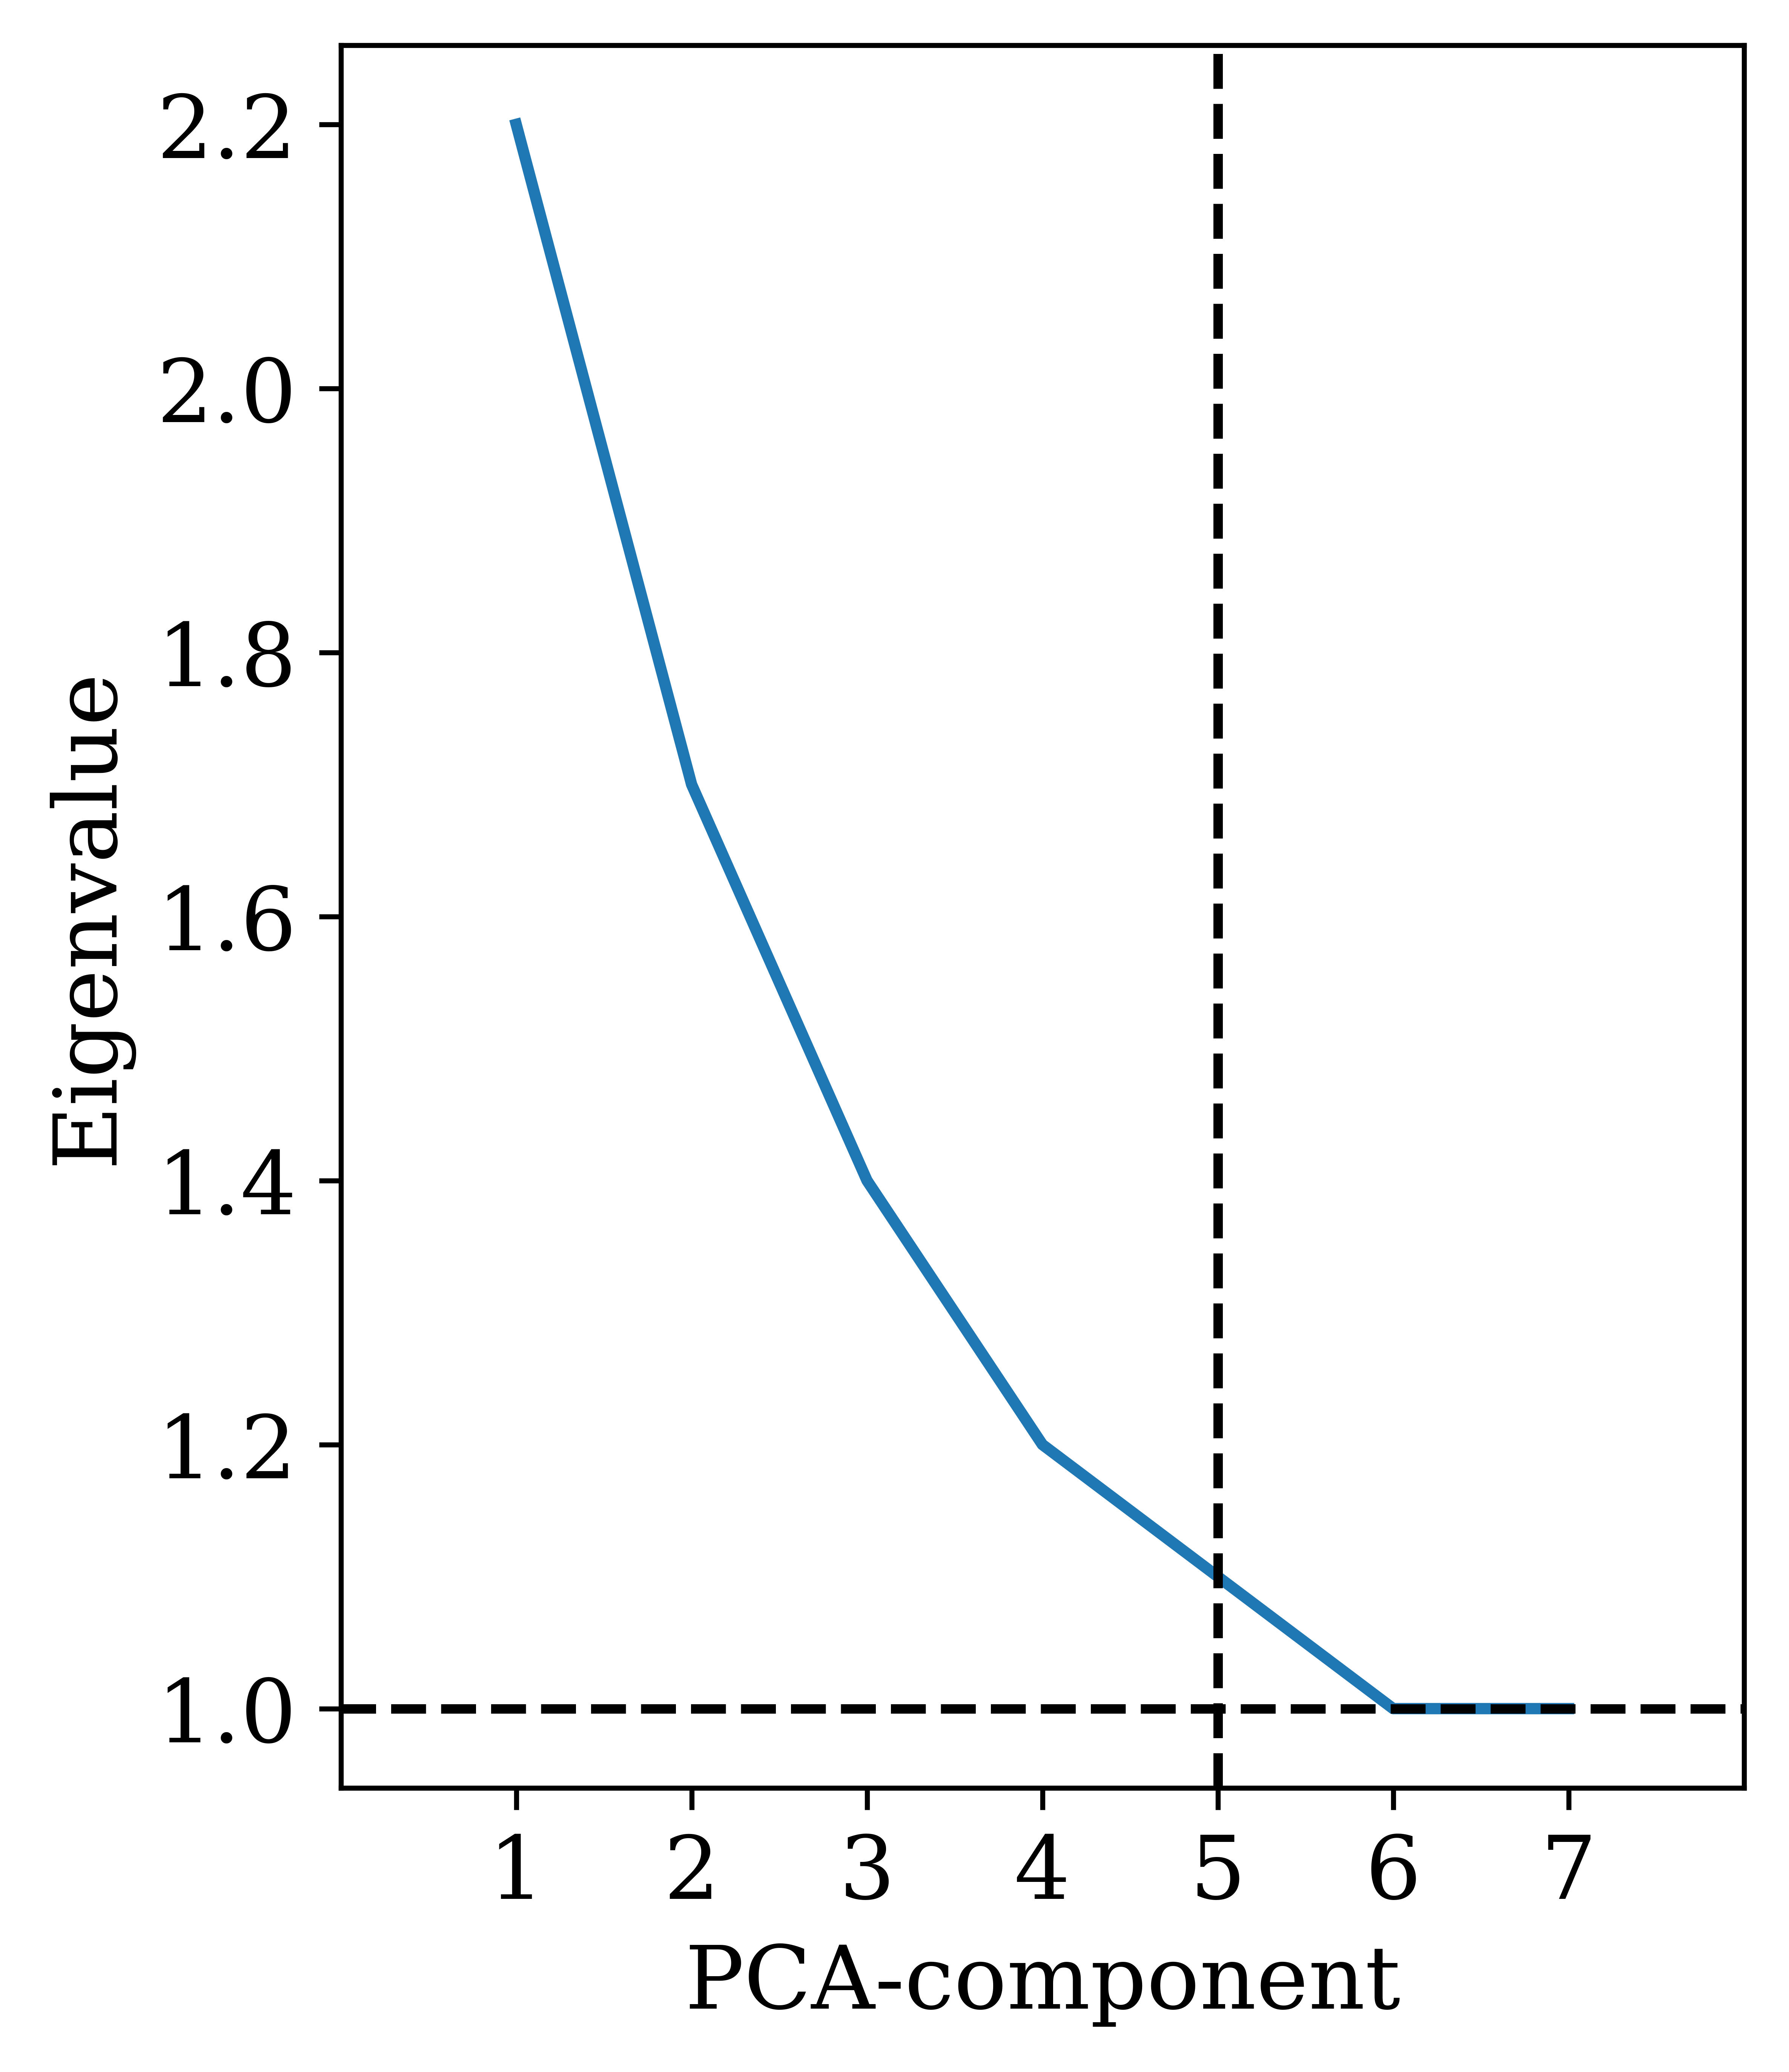

In [18]:
plt.rc('lines',lw=1.5,color='k')
plt.rc('font',family='serif',size=14)
plt.figure(figsize=(4,5),dpi=1200)
plt.plot(np.arange(1,8,1),np.round(pca.explained_variance_[:7],1),lw=1.8)
plt.xticks(np.arange(1,8,1))
plt.xlim([0,8])
plt.xlabel('PCA-component')
plt.ylabel('Eigenvalue')
plt.axvline(x=5,color='k',ls='--')
plt.axhline(y=1,color='k',ls='--')
plt.savefig("D:/Research/Mineral identifier ann IISER Mohali/ms and reference papers/AmMin Submission and Reviews/Revision 1/PCA_Kaiser_criterion.pdf",bbox_inches='tight')